# Загрузка данных и установка необходимых инструментов

In [58]:
# # RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
# import kagglehub
# kagglehub.login()


In [59]:
# home_credit_default_risk_path = kagglehub.competition_download('home-credit-default-risk')

# print('Data source import complete.')


In [119]:
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, average_precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, auc, classification_report, confusion_matrix, ConfusionMatrixDisplay, brier_score_loss
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool
import joblib
import json
import importlib
from sklearn.metrics import classification_report
import re

In [61]:
# print(home_credit_default_risk_path) # put dir that displays in pd.read.csv right before .../application_train.csv
# print(os.listdir(home_credit_default_risk_path))

In [62]:
df = pd.read_csv('C:/Users/volko/.cache/kagglehub/competitions/home-credit-default-risk/application_train.csv')
pd.set_option('display.max.columns', None)
df.head()

print(f"размер: {df.shape}")
print(f"типы данных:\n{df.dtypes.value_counts()}")
df.describe()

размер: (307511, 122)
типы данных:
float64    65
int64      41
str        16
Name: count, dtype: int64


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,0.042553,0.074490,0.145193,0.222315,0.228058,0.064958,0.105645,0.105975,0.008076,0.027022,0.117850,0.087955,0.97

## Проверим насколько нулевой класс доминирует над первым


In [63]:
print(df['TARGET'].value_counts())
print()
print(df['TARGET'].value_counts(normalize=True))

negative = (df['TARGET'] == 0).sum()
positive = (df['TARGET'] == 1).sum()

print("\n")
print(f"class 0: {negative}")
print(f"class 1: {positive}")
print(f"ratio 0/1: {negative / positive:.2f}")

TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


class 0: 282686
class 1: 24825
ratio 0/1: 11.39


# РАЗВЕДОЧНЫЙ АНАЛИЗ


Баланс классов:
TARGET
0    282686
1     24825
Name: count, dtype: int64
Доля дефолтов: 8.07%


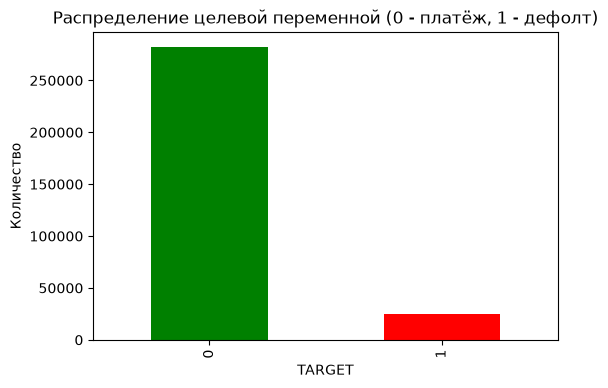

In [64]:
# Визуализация дисбаланса
print(f"\nБаланс классов:\n{df['TARGET'].value_counts()}")
print(f"Доля дефолтов: {df['TARGET'].mean():.2%}")

plt.figure(figsize=(6,4))
df['TARGET'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Распределение целевой переменной (0 - платёж, 1 - дефолт)')
plt.xlabel('TARGET')
plt.ylabel('Количество')
plt.show()

## Обработка пропусков


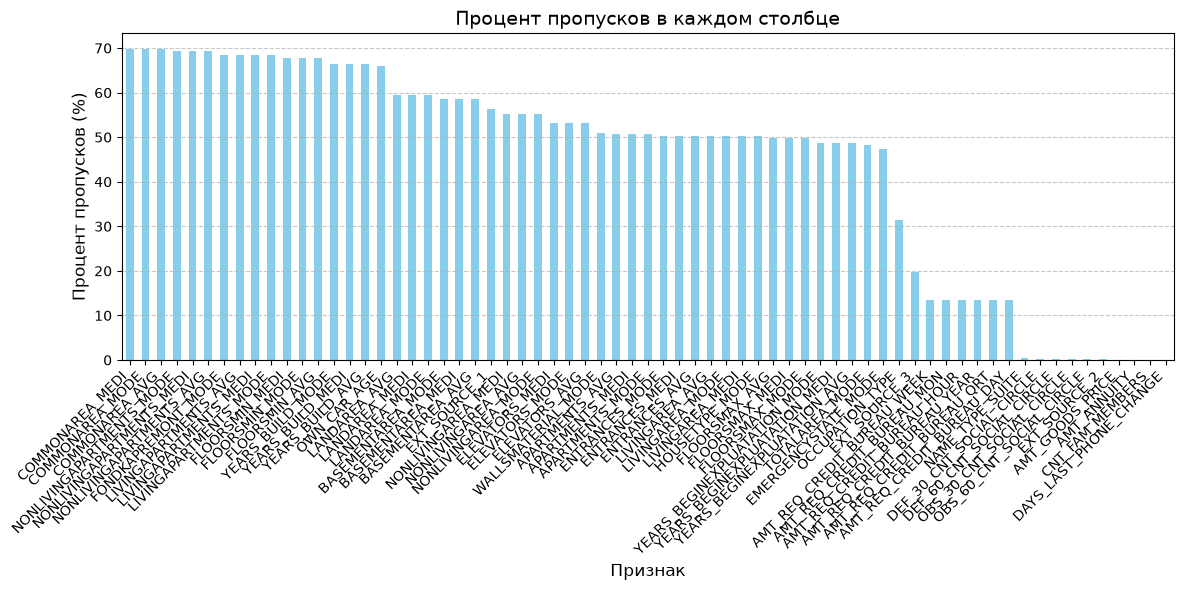

In [65]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)


plt.figure(figsize=(12, 6))
missing_percent.plot(kind='bar', color='skyblue')
plt.title('Процент пропусков в каждом столбце', fontsize=14)
plt.xlabel('Признак', fontsize=12)
plt.ylabel('Процент пропусков (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Теперь посмотрим на корреляцию между таргетом и столбцами, содержащими AVG, MEDI, MODE


NONLIVINGAPARTMENTS_MODE                 -0.001557
NONLIVINGAPARTMENTS_MEDI                 -0.002757
NONLIVINGAPARTMENTS_AVG                  -0.003176
YEARS_BEGINEXPLUATATION_MODE             -0.009036
YEARS_BEGINEXPLUATATION_AVG              -0.009728
YEARS_BEGINEXPLUATATION_MEDI             -0.009993
LANDAREA_MODE                            -0.010174
LANDAREA_AVG                             -0.010885
LANDAREA_MEDI                            -0.011256
NONLIVINGAREA_MODE                       -0.012711
NONLIVINGAREA_MEDI                       -0.013337
NONLIVINGAREA_AVG                        -0.013578
COMMONAREA_MODE                          -0.016340
ENTRANCES_MODE                           -0.017387
COMMONAREA_AVG                           -0.018550
COMMONAREA_MEDI                          -0.018573
ENTRANCES_MEDI                           -0.019025
ENTRANCES_AVG                            -0.019172
BASEMENTAREA_MODE                        -0.019952
YEARS_BUILD_MODE               

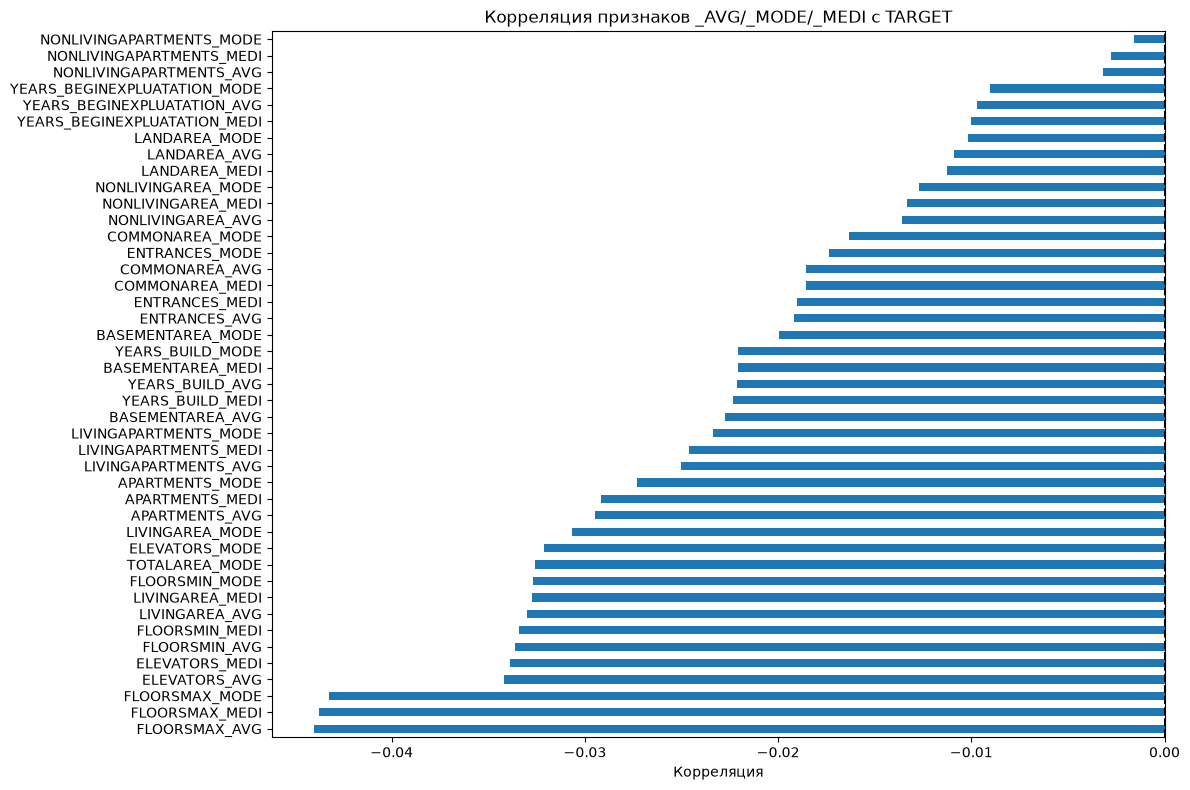

In [66]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# filtering _AVG, _MODE, _MEDI
avg_mode_medi = [col for col in numeric_cols if any(x in col for x in ['_AVG', '_MODE', '_MEDI'])]
# correlation with target
corr_avg_mode_medi = df[avg_mode_medi + ['TARGET']].corr()['TARGET'].sort_values(ascending=False)

for col, corr in corr_avg_mode_medi.items():
    if col != 'TARGET':
        print(f"{col:40s} {corr:.6f}")

plt.figure(figsize=(12, 8))
corr_avg_mode_medi.drop('TARGET').sort_values().plot(kind='barh')
plt.title('Корреляция признаков _AVG/_MODE/_MEDI с TARGET')
plt.xlabel('Корреляция')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


### Получили, что корреляция у таргета и выбранных нами столбцов близка к нулю, то есть они по сути бесполезны, к тому же еще и имеют огромное количество пропусков

Общее число категориальных столбцов: 16
Число категориальных столбцов с пропусками: 6


C:\Users\volko\AppData\Local\Temp\ipykernel_10916\1087343647.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


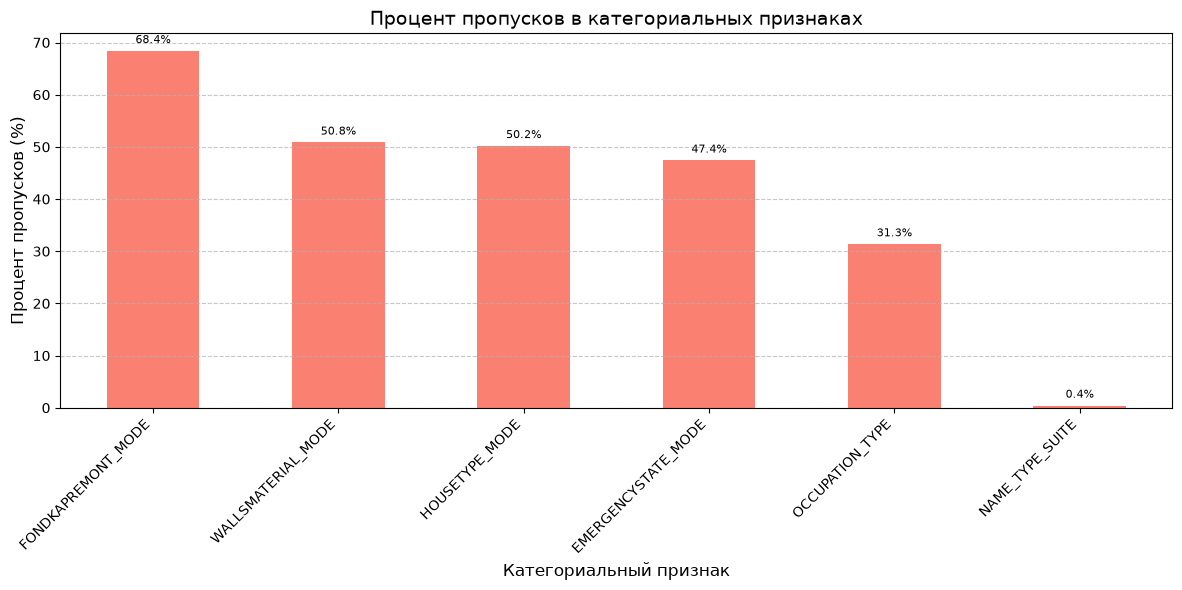

In [67]:
cat_cols = df.select_dtypes(include=['object']).columns
print('Общее число категориальных столбцов:', len(cat_cols))
print('Число категориальных столбцов с пропусками: 6')
missing_percent_cat = (df[cat_cols].isnull().sum() / len(df)) * 100
missing_percent_cat = missing_percent_cat[missing_percent_cat > 0].sort_values(ascending=False)

if len(missing_percent_cat) > 0:
    plt.figure(figsize=(12, 6))
    missing_percent_cat.plot(kind='bar', color='salmon')
    plt.title('Процент пропусков в категориальных признаках', fontsize=14)
    plt.xlabel('Категориальный признак', fontsize=12)
    plt.ylabel('Процент пропусков (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for i, v in enumerate(missing_percent_cat):
        plt.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

### Первые 3 признака по количеству пропусков удалим в виду их неинформативности и специфичности, оставшиеся заполним 'Unknown'


In [68]:
cols_to_drop = ['FONDKAPREMONT_MODE', 'WALLSMATERIAL_MODE', 'HOUSETYPE_MODE']
df = df.drop(columns=cols_to_drop, errors='ignore')
df = df.drop(columns=avg_mode_medi, errors='ignore')
print(f"Удалены столбцы: {cols_to_drop}")

# processing all the rest categorical variables
cat_cols_to_keep = ['EMERGENCYSTATE_MODE', 'OCCUPATION_TYPE', 'NAME_TYPE_SUITE']

for col in cat_cols_to_keep:
    df[col] = df[col].fillna('Unknown')

    if col == 'OCCUPATION_TYPE':
        df['OCCUPATION_UNKNOWN'] = (df['OCCUPATION_TYPE'] == 'Unknown').astype(int)

print(f"\nПроверка пропусков в категориальных колонках:")
print(df[cat_cols_to_keep].isnull().sum())

Удалены столбцы: ['FONDKAPREMONT_MODE', 'WALLSMATERIAL_MODE', 'HOUSETYPE_MODE']

Проверка пропусков в категориальных колонках:
EMERGENCYSTATE_MODE    0
OCCUPATION_TYPE        0
NAME_TYPE_SUITE        0
dtype: int64


## Чистим оставшиеся бесполезные числовые столбцы: различные флаги, которые лишь раздувают датасет и не несут особой информативности


In [69]:
# SK_ID_CURR becomes the index: it is not a feature, but it is needed to join the credit history tables
df = df.set_index('SK_ID_CURR')

cols_to_drop = ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
                'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OWN_CAR_AGE']
doc_flags = [col for col in df.columns if col.startswith('FLAG_DOCUMENT_')]
cols_to_drop.extend(doc_flags)
df = df.drop(columns=cols_to_drop)
print(f"Удалено ID и флаги: {len(cols_to_drop)}")

# processing DAYS_EMPLOYED
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

# numeric gaps are left as nan: tree models handle them natively,
# and the fact of missing is a signal itself (e.g. DAYS_EMPLOYED is missing for pensioners)

print(f"\nОсталось столбцов: {df.shape[1]}")
print(f"Осталось пропусков: {df.isnull().sum().sum()}")
print(f"Числовых столбцов: {len(df.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"Категориальных: {len(df.select_dtypes(include=['object']).columns)}")

Удалено ID и флаги: 27

Осталось столбцов: 49
Осталось пропусков: 543868
Числовых столбцов: 36
Категориальных: 13


C:\Users\volko\AppData\Local\Temp\ipykernel_10916\986459359.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"Категориальных: {len(df.select_dtypes(include=['object']).columns)}")


## Далее рассмотрим распределения основных числовых характеристик




### Для того, чтоб определить, какие из них по-настоящему важны, рассмотрим их корреляцию с таргетом

In [70]:
# correlation of all numerical features with TARGET
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlations = df[numeric_cols].corr()['TARGET'].abs().sort_values(ascending=False)

# displaying top 15
print("Топ-15 признаков по корреляции с TARGET")
for col, corr in correlations.head(20).items():
    if col != 'TARGET':
        print(f"{col:30s} {corr:.4f}")

Топ-15 признаков по корреляции с TARGET
EXT_SOURCE_3                   0.1789
EXT_SOURCE_2                   0.1605
EXT_SOURCE_1                   0.1553
DAYS_BIRTH                     0.0782
DAYS_EMPLOYED                  0.0750
REGION_RATING_CLIENT_W_CITY    0.0609
REGION_RATING_CLIENT           0.0589
DAYS_LAST_PHONE_CHANGE         0.0552
DAYS_ID_PUBLISH                0.0515
REG_CITY_NOT_WORK_CITY         0.0510
REG_CITY_NOT_LIVE_CITY         0.0444
DAYS_REGISTRATION              0.0420
AMT_GOODS_PRICE                0.0396
OCCUPATION_UNKNOWN             0.0387
REGION_POPULATION_RELATIVE     0.0372
LIVE_CITY_NOT_WORK_CITY        0.0325
DEF_30_CNT_SOCIAL_CIRCLE       0.0322
DEF_60_CNT_SOCIAL_CIRCLE       0.0313
AMT_CREDIT                     0.0304


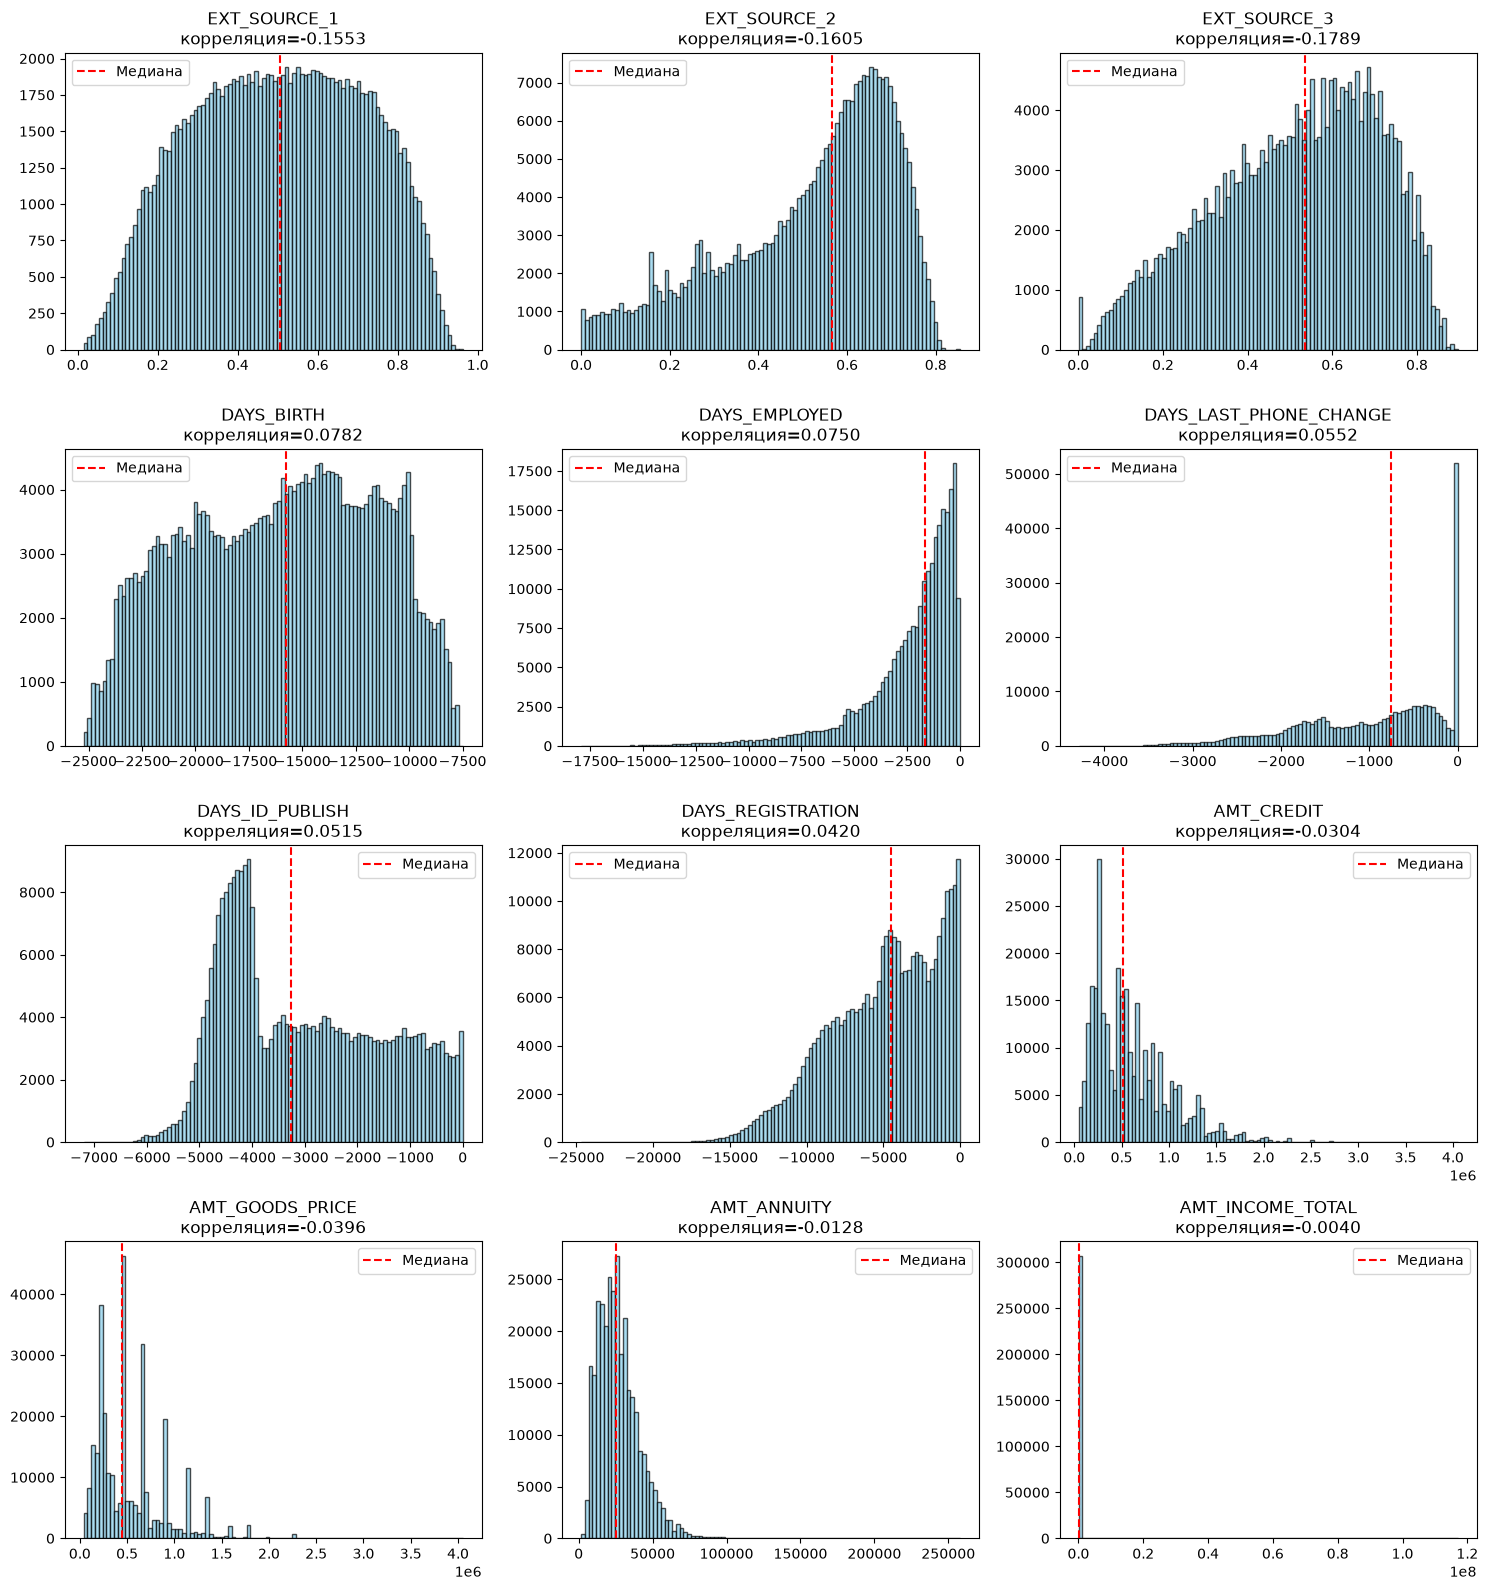

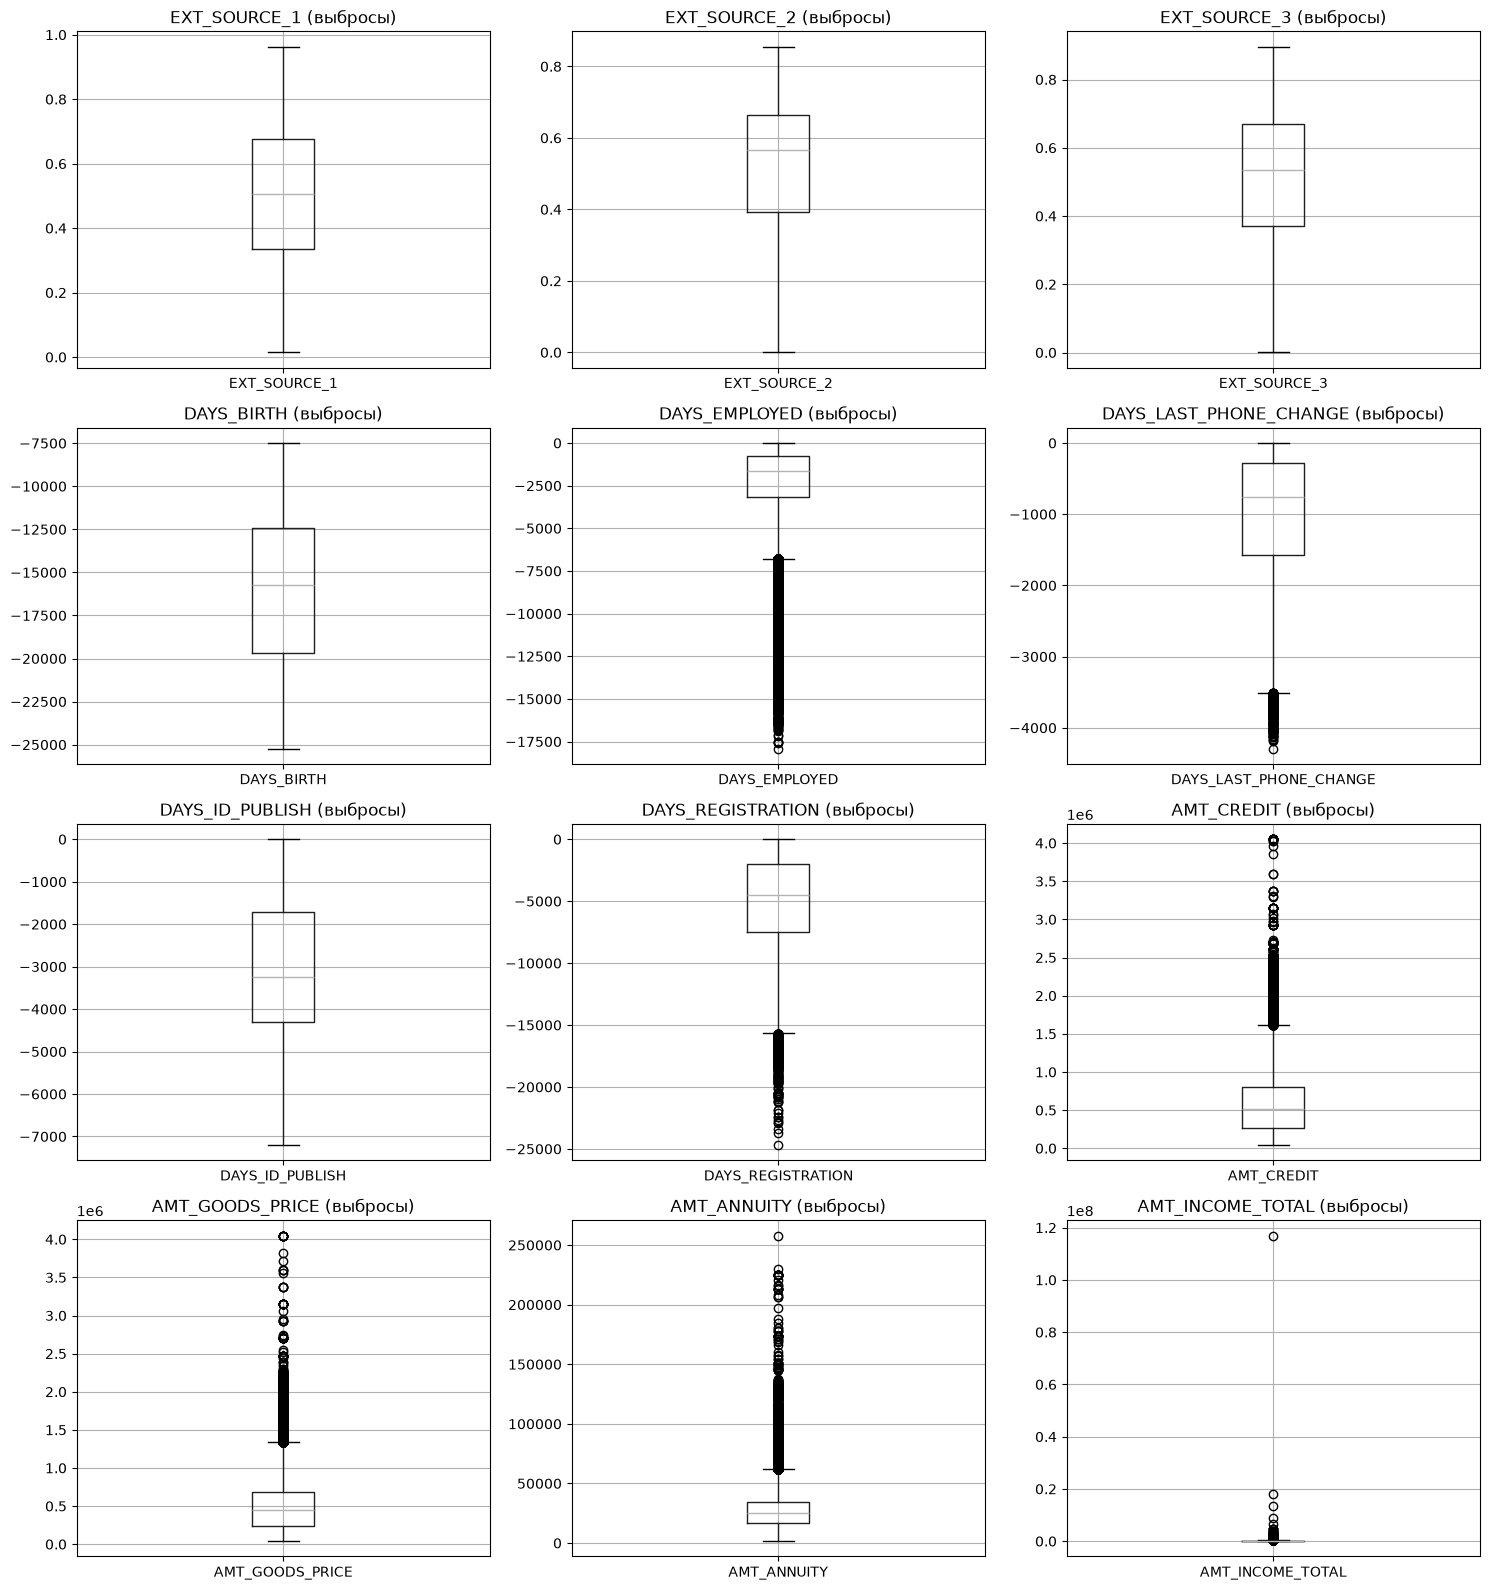

In [71]:
top_features = [
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',

    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'DAYS_LAST_PHONE_CHANGE',
    'DAYS_ID_PUBLISH',
    'DAYS_REGISTRATION',

    'AMT_CREDIT',
    'AMT_GOODS_PRICE',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL'
]

n_cols = 3
n_rows = math.ceil(len(top_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(top_features):

    data = df[col].dropna()

    axes[i].hist(
        data,
        bins=100,
        color='skyblue',
        edgecolor='black',
        alpha=0.7
    )

    corr = df[col].corr(df['TARGET'])

    axes[i].set_title(
        f'{col}\nкорреляция={corr:.4f}'
    )

    axes[i].axvline(
        data.median(),
        color='red',
        linestyle='--',
        label='Медиана'
    )

    axes[i].legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(top_features):
    if col in df.columns:
        df.boxplot(column=col, ax=axes[i])
        axes[i].set_title(f'{col} (выбросы)')

plt.tight_layout()
plt.show()

Созданы логарифмические признаки

Добавлены признаки:
AMT_CREDIT_LOG
AMT_GOODS_PRICE_LOG
AMT_ANNUITY_LOG
AMT_INCOME_TOTAL_LOG

Размер датасета: (307511, 53)


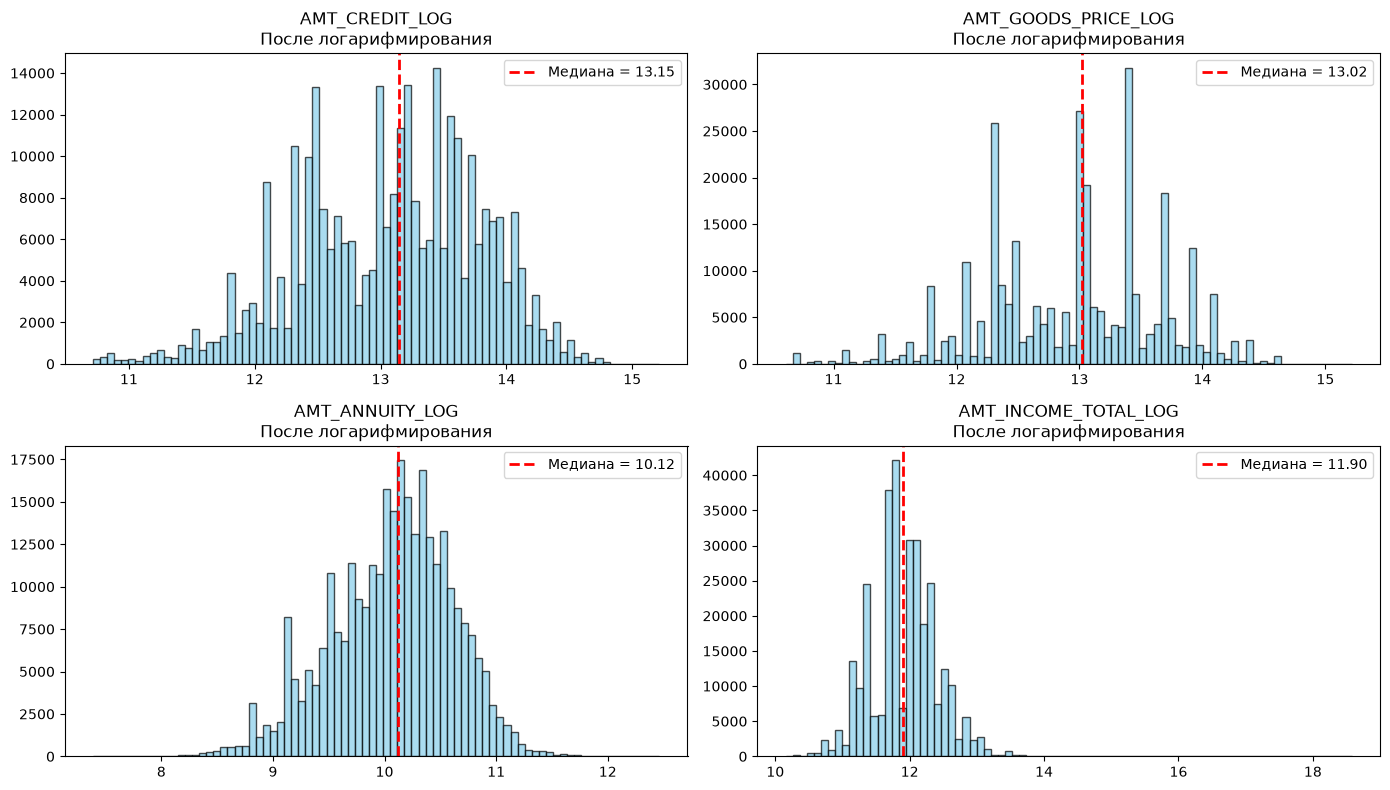

In [ ]:
# quantiles calculated over the whole df leak information from the test part

log_cols = [
    'AMT_CREDIT',
    'AMT_GOODS_PRICE',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL'
]

for col in log_cols:
    df[f'{col}_LOG'] = np.log1p(df[col])
print("Созданы логарифмические признаки")


print("\nДобавлены признаки:")
for col in log_cols:
    print(f'{col}_LOG')
print(f'\nРазмер датасета: {df.shape}')


features_to_check = [
    ('AMT_CREDIT_LOG', 'После логарифмирования'),
    ('AMT_GOODS_PRICE_LOG', 'После логарифмирования'),
    ('AMT_ANNUITY_LOG', 'После логарифмирования'),
    ('AMT_INCOME_TOTAL_LOG', 'После логарифмирования')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (col, title) in enumerate(features_to_check):
    data = df[col].dropna()

    axes[i].hist(
        data,
        bins=80,
        color='skyblue',
        edgecolor='black',
        alpha=0.7
    )

    axes[i].axvline(
        data.median(),
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Медиана = {data.median():.2f}'
    )

    axes[i].set_title(f'{col}\n{title}')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Генерация фичей


In [73]:
df['AGE'] = -df['DAYS_BIRTH'] / 365
df['EMPLOYMENT_YEARS'] = -df['DAYS_EMPLOYED'] / 365


# fin coefs
df['DEBT_TO_INCOME'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df['ANNUITY_TO_INCOME'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['CREDIT_TO_GOODS'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']

# external scoring sources
df['EXT_SOURCE_MEAN'] = (
    df[['EXT_SOURCE_1',
        'EXT_SOURCE_2',
        'EXT_SOURCE_3']]
    .mean(axis=1)
)

df['EXT_SOURCE_PROD'] = (
    df['EXT_SOURCE_1'] *
    df['EXT_SOURCE_2'] *
    df['EXT_SOURCE_3']
)

# social environment
df['SOCIAL_DEF_RATIO_30'] = (
    df['DEF_30_CNT_SOCIAL_CIRCLE'] /
    (df['OBS_30_CNT_SOCIAL_CIRCLE'] + 1)
)

df['SOCIAL_DEF_RATIO_60'] = (
    df['DEF_60_CNT_SOCIAL_CIRCLE'] /
    (df['OBS_60_CNT_SOCIAL_CIRCLE'] + 1)
)

# ratio of length of service to age
df['EMPLOYMENT_RATIO'] = (
    df['DAYS_EMPLOYED'] /
    df['DAYS_BIRTH']
)


### Посмотрим на корреляцию новых признаков

Корреляция новых фич с таргетом
               Feature  Correlation
5      EXT_SOURCE_MEAN     0.222052
6      EXT_SOURCE_PROD     0.188552
0                  AGE     0.078239
1     EMPLOYMENT_YEARS     0.074958
4      CREDIT_TO_GOODS     0.069427
9     EMPLOYMENT_RATIO     0.067955
7  SOCIAL_DEF_RATIO_30     0.032139
8  SOCIAL_DEF_RATIO_60     0.029870
3    ANNUITY_TO_INCOME     0.014265
2       DEBT_TO_INCOME     0.007727


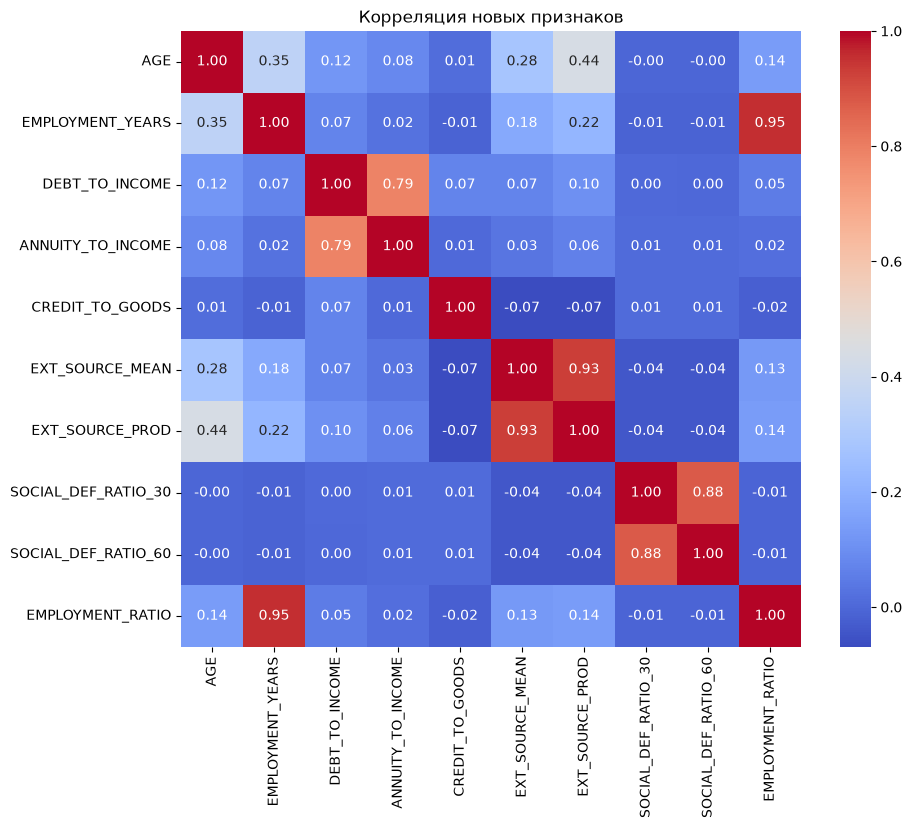

In [74]:
new_features = [
    'AGE',
    'EMPLOYMENT_YEARS',
    'DEBT_TO_INCOME',
    'ANNUITY_TO_INCOME',
    'CREDIT_TO_GOODS',
    'EXT_SOURCE_MEAN',
    'EXT_SOURCE_PROD',
    'SOCIAL_DEF_RATIO_30',
    'SOCIAL_DEF_RATIO_60',
    'EMPLOYMENT_RATIO'
]

corr_df = pd.DataFrame({
    'Feature': new_features,
    'Correlation': [
        abs(df[col].corr(df['TARGET']))
        for col in new_features
    ]
})

corr_df.sort_values(
    'Correlation',
    ascending=False,
    inplace=True
)

print('Корреляция новых фич с таргетом')
print(corr_df)

corr_matrix = df[new_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.title('Корреляция новых признаков')
plt.show()

# ОБУЧЕНИЕ МОДЕЛЕЙ


In [75]:
# firstly we will check all remaining data for missing values
# numeric gaps are left as nan on purpose, only bureau requests are filled with zeros in the next cell

print(df.shape)
print(df.isna().sum().sum())
print(df.dtypes.value_counts())

pd.DataFrame({
    'missing': df.isna().sum(),
    'percent': df.isna().mean() * 100
}).query('missing > 0').sort_values('missing', ascending=False)

(307511, 63)
855332
float64    36
int64      14
str        13
Name: count, dtype: int64


,missing,percent
EXT_SOURCE_PROD,197922,64.362576
EXT_SOURCE_1,173378,56.381073
EXT_SOURCE_3,60965,19.825307
DAYS_EMPLOYED,55374,18.007161
EMPLOYMENT_YEARS,55374,18.007161
EMPLOYMENT_RATIO,55374,18.007161
AMT_REQ_CREDIT_BUREAU_MON,41519,13.501631
AMT_REQ_CREDIT_BUREAU_QRT,41519,13.501631
AMT_REQ_CREDIT_BUREAU_HOUR,41519,13.501631
AMT_REQ_CREDIT_BUREAU_WEEK,41519,13.501631


### Заполним найденные пропуски в оставшихся данных

In [76]:
# credit bureau requests with nulls
bureau_cols = [
    'AMT_REQ_CREDIT_BUREAU_HOUR',
    'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR'
]

df[bureau_cols] = df[bureau_cols].fillna(0)


# the rest of numeric gaps are left as nan on purpose
missing_total = df.isna().sum().sum()

print(f"remaining missing values: {missing_total:,} (numeric nan, handled by the models natively)")
print(f"columns with missing values: {(df.isna().sum() > 0).sum()}")

remaining missing values: 606,218 (numeric nan, handled by the models natively)
columns with missing values: 22


In [108]:
df_model = pd.get_dummies(df, drop_first=True)
X = df_model.drop('TARGET', axis=1)
y = df_model['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=3
)

print(X_train.shape)
print(X_test.shape)
def evaluate_model(model, X_test, y_test, model_name, threshold=0.5, fn_to_fp_cost=5, verbose=True):

    # predictions
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    # metrics that depend on the threshold
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    cost_per_100 = (fp + fn_to_fp_cost * fn) / len(y_test) * 100

    # ranking metrics, they don't depend on the threshold
    roc_auc = roc_auc_score(y_test, y_proba)
    gini = 2 * roc_auc - 1
    pr_auc = average_precision_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ks = np.max(tpr - fpr)

    if verbose:
        # displaying metrics
        print("=" * 60)
        print(model_name)
        print("=" * 60)

        print(f"Threshold: {threshold:.4f}")
        print(f"Accuracy : {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1-score : {f1:.4f}")
        print(f"Cost/100 : {cost_per_100:.2f}")
        print(f"ROC-AUC  : {roc_auc:.4f}")
        print(f"Gini     : {gini:.4f}")
        print(f"PR-AUC   : {pr_auc:.4f}")
        print(f"KS       : {ks:.4f}")

        # confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay(
            confusion_matrix=cm
        ).plot(ax=ax)
        ax.set_title(f'{model_name}\nConfusion Matrix')
        plt.show()

        # ROC curve
        plt.figure(figsize=(6, 5))
        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f'ROC-AUC = {roc_auc:.4f}'
        )

        plt.plot(
            [0, 1],
            [0, 1],
            '--'
        )

        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{model_name}\nROC Curve')

        plt.legend()
        plt.grid(True)

        plt.show()

    return {
        'Model': model_name,
        'Threshold': threshold,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Cost_per_100': cost_per_100,
        'ROC_AUC': roc_auc,
        'Gini': gini,
        'PR_AUC': pr_auc,
        'KS': ks
    }


def cross_validate_model(model, X, y, model_name, threshold=0.5, fn_to_fp_cost=5, n_splits=5, experiment_name=None, fit_params=None):

    # stratified k-fold: every fold keeps the same default rate as the whole train
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=3
    )

    fold_results = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):

        # a fresh untrained copy of the model for every fold
        fold_model = clone(model)
        # fit_params are passed to fit(), e.g. cat_features for catboost
        fold_model.fit(X.iloc[train_idx], y.iloc[train_idx], **(fit_params or {}))

        metrics = evaluate_model(
            fold_model,
            X.iloc[valid_idx],
            y.iloc[valid_idx],
            f'{model_name} fold {fold}',
            threshold=threshold,
            fn_to_fp_cost=fn_to_fp_cost,
            verbose=False
        )
        fold_results.append(metrics)

        print(
            f"fold {fold}: gini={metrics['Gini']:.4f}, pr_auc={metrics['PR_AUC']:.4f}, "
            f"ks={metrics['KS']:.4f}, cost_per_100={metrics['Cost_per_100']:.2f}"
        )

    fold_results = pd.DataFrame(fold_results)

    # mean and std over folds: std shows how much the metric changes just because of the split
    metric_cols = ['ROC_AUC', 'Gini', 'PR_AUC', 'KS', 'Precision', 'Recall', 'Cost_per_100']
    summary = fold_results[metric_cols].agg(['mean', 'std']).T

    print("=" * 80)
    print(f"{model_name}: {n_splits}-fold cross-validation")
    print("=" * 80)
    print(summary.round(4))

    # saving the fold results to compare experiments with each other
    if experiment_name is not None:
        os.makedirs('../reports', exist_ok=True)
        fold_results.to_csv(f'../reports/cv_{experiment_name}.csv', index=False)
        print(f"saved: ../reports/cv_{experiment_name}.csv")

    return fold_results

(246008, 165)
(61503, 165)


In [78]:
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=3
)

print("train:", X_train_part.shape)
print("validation:", X_val.shape)
print("test:", X_test.shape)

train: (196806, 165)
validation: (49202, 165)
test: (61503, 165)


## Логистическая регрессия


Logistic Regression
Threshold: 0.5000
Accuracy : 0.6902
Precision: 0.1630
Recall   : 0.6860
F1-score : 0.2634
Cost/100 : 41.12
ROC-AUC  : 0.7521
Gini     : 0.5041
PR-AUC   : 0.2291
KS       : 0.3800


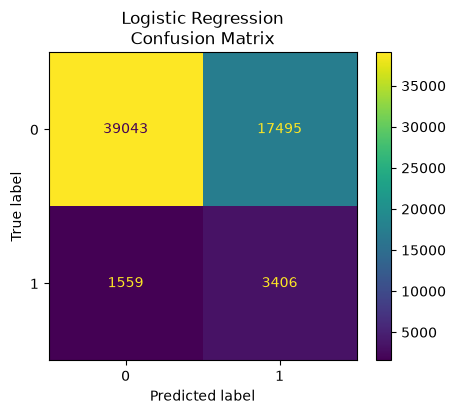

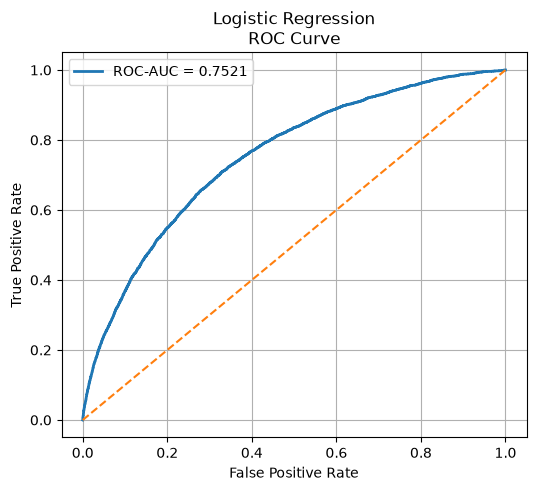

In [79]:
# logistic regression doesn't support nan, so the imputer is a part of the pipeline
# medians are calculated on the train part only, no leakage to test
log_reg = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=3000,
        random_state=3
    ))
])

log_reg.fit(X_train, y_train)
log_reg_result = evaluate_model(
    log_reg,
    X_test,
    y_test,
    'Logistic Regression'
)

## Random Forest


Random Forest
Threshold: 0.5000
Accuracy : 0.7133
Precision: 0.1700
Recall   : 0.6572
F1-score : 0.2701
Cost/100 : 39.74
ROC-AUC  : 0.7497
Gini     : 0.4995
PR-AUC   : 0.2277
KS       : 0.3790


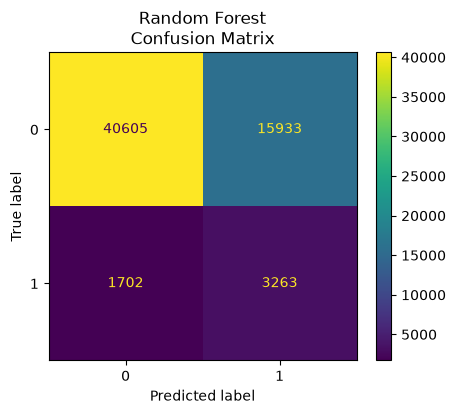

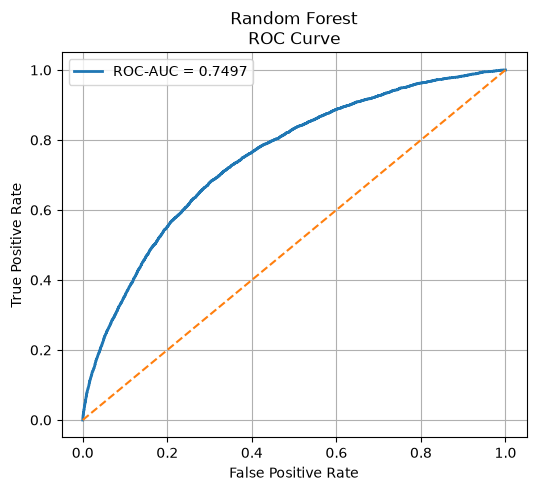

In [80]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=3,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_result = evaluate_model(
    rf,
    X_test,
    y_test,
    'Random Forest'
)

## XGBoost

XGBoost
Threshold: 0.5000
Accuracy : 0.7265
Precision: 0.1775
Recall   : 0.6568
F1-score : 0.2794
Cost/100 : 38.43
ROC-AUC  : 0.7648
Gini     : 0.5297
PR-AUC   : 0.2494
KS       : 0.3957


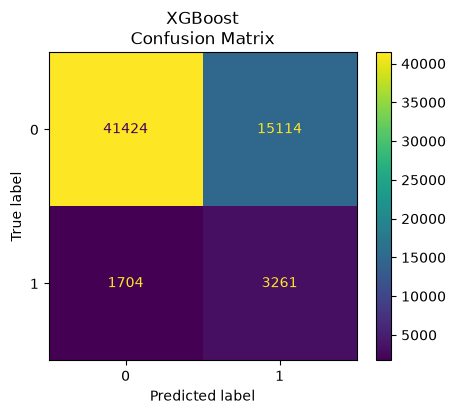

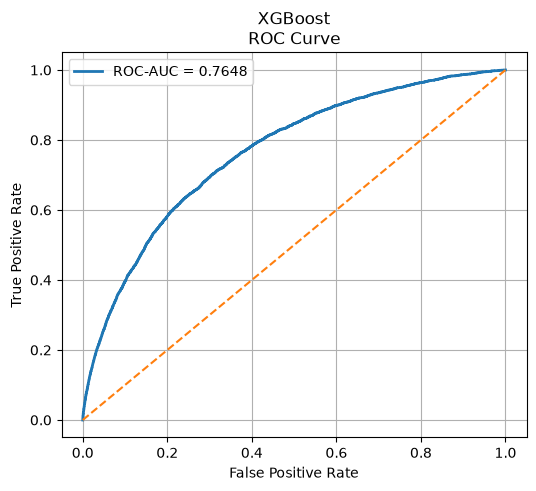

In [81]:
scale_pos_weight = (
    (y_train == 0).sum()
    /
    (y_train == 1).sum()
)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=3,
    eval_metric='logloss',
)

xgb.fit(X_train, y_train)
xgb_result = evaluate_model(
    xgb,
    X_test,
    y_test,
    'XGBoost'
)

## LightGBM

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013937 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6615
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 159
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

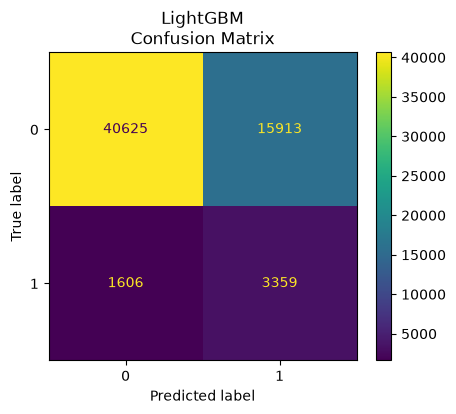

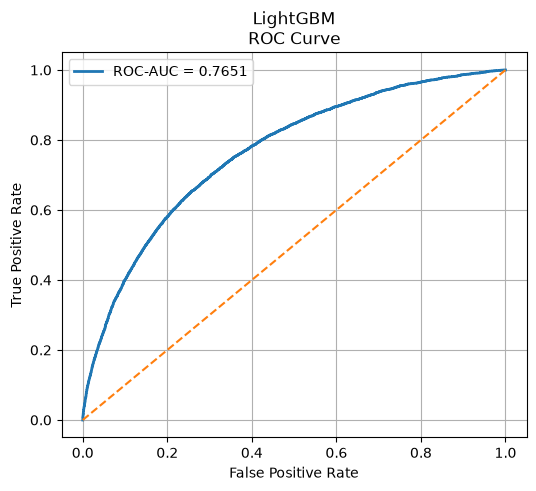

In [82]:
# lightgbm doesn't accept special characters in feature names, so it gets its own renamed copies
# X_train / X_test stay unchanged, otherwise catboost below would get different feature names
X_train_lgbm = X_train.copy()
X_test_lgbm = X_test.copy()

X_train_lgbm.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in X_train_lgbm.columns
]

X_test_lgbm.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in X_test_lgbm.columns
]

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    class_weight='balanced',
    random_state=3
)

lgbm.fit(X_train_lgbm, y_train)
lgbm_result = evaluate_model(
    lgbm,
    X_test_lgbm,
    y_test,
    'LightGBM'
)

## CatBoost

CatBoost
Threshold: 0.5000
Accuracy : 0.9198
Precision: 0.6159
Recall   : 0.0187
F1-score : 0.0364
Cost/100 : 39.70
ROC-AUC  : 0.7657
Gini     : 0.5314
PR-AUC   : 0.2516
KS       : 0.3979


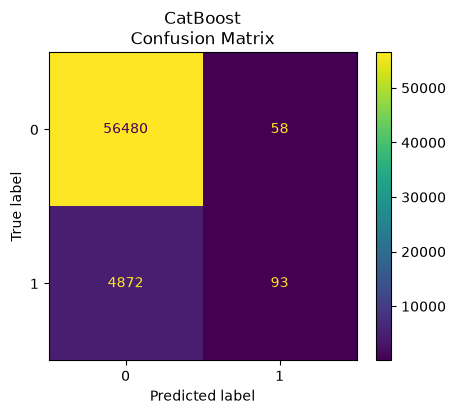

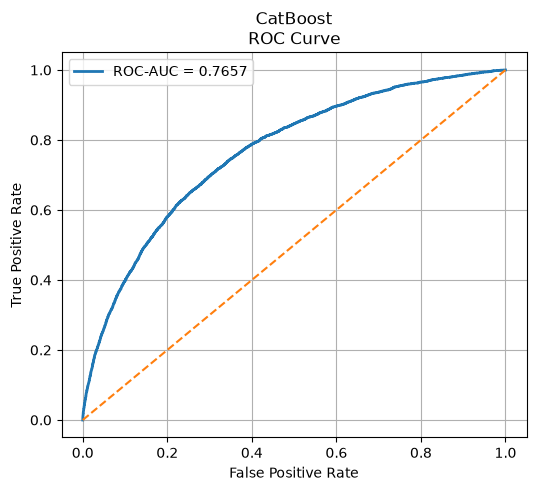

In [83]:
cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=3,
    verbose=0
)

cat.fit(X_train_part, y_train_part)

cat_result = evaluate_model(
    cat,
    X_test,
    y_test,
    'CatBoost'
)

# Борьба с дисбалансом классов и исследование поведения модели

## Подбор порога по стоимости ошибок

In [109]:
# threshold selection based on the cost of errors
# fn - missed defaulter (we lose part of the loan), fp - rejected good client (we lose the margin)
# only the relative cost matters, so fp cost is fixed to 1 and fn cost = ratio

y_val_proba = cat.predict_proba(X_val)[:, 1]

# calibration sanity check: for a well calibrated model these two numbers are close
print(f"mean predicted probability: {y_val_proba.mean():.4f}")
print(f"actual default rate: {y_val.mean():.4f}")

thresholds = np.arange(0.01, 0.51, 0.01)
cost_ratios = [2, 3, 5, 7, 10]
results = []

for ratio in cost_ratios:
    costs = []

    for threshold in thresholds:
        y_val_pred = (y_val_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()
        costs.append(fp + ratio * fn)

    best_threshold = thresholds[np.argmin(costs)]
    y_val_pred = (y_val_proba >= best_threshold).astype(int)

    results.append({
        'fn_to_fp_cost': ratio,
        'best_threshold': best_threshold,
        'theory_threshold': 1 / (1 + ratio),
        'precision': precision_score(y_val, y_val_pred, zero_division=0),
        'recall': recall_score(y_val, y_val_pred, zero_division=0),
        'rejected_share': y_val_pred.mean()
    })

cost_results = pd.DataFrame(results)
cost_results

mean predicted probability: 0.0800
actual default rate: 0.0807


,fn_to_fp_cost,best_threshold,theory_threshold,precision,recall,rejected_share
0,2,0.33,0.333333,0.434466,0.090131,0.016747
1,3,0.24,0.250000,0.329588,0.199396,0.048839
2,5,0.15,0.166667,0.242986,0.412135,0.136925
3,7,0.12,0.125000,0.212027,0.513092,0.195358
4,10,0.10,0.090909,0.188056,0.590634,0.253547


In [110]:
# final threshold from the business cost ratio
# the model is well calibrated, so we take the theoretical threshold instead of the one tuned on validation
fn_to_fp_cost = 5
final_threshold = 1 / (1 + fn_to_fp_cost)

print(f"final threshold: {final_threshold:.4f}")

# checking the threshold on validation and test: the numbers should be close
check_results = []

for sample_name, X_sample, y_sample in [
    ('validation', X_val, y_val),
    ('test', X_test, y_test)
]:
    y_sample_proba = cat.predict_proba(X_sample)[:, 1]
    y_sample_pred = (y_sample_proba >= final_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_sample, y_sample_pred).ravel()

    check_results.append({
        'sample': sample_name,
        'precision': precision_score(y_sample, y_sample_pred, zero_division=0),
        'recall': recall_score(y_sample, y_sample_pred, zero_division=0),
        'rejected_share': y_sample_pred.mean(),
        'cost_per_100': (fp + fn_to_fp_cost * fn) / len(y_sample) * 100,
        'mean_proba': y_sample_proba.mean(),
        'default_rate': y_sample.mean()
    })

# detailed report on test
y_test_pred = (cat.predict_proba(X_test)[:, 1] >= final_threshold).astype(int)
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))

pd.DataFrame(check_results)

final threshold: 0.1667
              precision    recall  f1-score   support

           0       0.94      0.91      0.93     56538
           1       0.27      0.37      0.31      4965

    accuracy                           0.87     61503
   macro avg       0.61      0.64      0.62     61503
weighted avg       0.89      0.87      0.88     61503

[[51509  5029]
 [ 3110  1855]]


,sample,precision,recall,rejected_share,cost_per_100,mean_proba,default_rate
0,validation,0.257020,0.361782,0.113634,34.203894,0.079957,0.080728
1,test,0.269465,0.373615,0.111929,33.460156,0.080224,0.080728


## Кросс-валидация

In [86]:
# cross-validation of catboost, fold results are saved to reports/cv_<experiment_name>.csv
# only X_train is used here, X_test stays untouched until the final check
cat_cv = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=3,
    verbose=0
)

cat_cv_results = cross_validate_model(
    cat_cv,
    X_train,
    y_train,
    'CatBoost',
    threshold=final_threshold,
    experiment_name='no_imputation'
)

fold 0: gini=0.5141, pr_auc=0.2473, ks=0.3790, cost_per_100=34.18
fold 1: gini=0.5272, pr_auc=0.2475, ks=0.3911, cost_per_100=33.41
fold 2: gini=0.5028, pr_auc=0.2358, ks=0.3694, cost_per_100=34.67
fold 3: gini=0.5146, pr_auc=0.2386, ks=0.3864, cost_per_100=34.03
fold 4: gini=0.5129, pr_auc=0.2375, ks=0.3794, cost_per_100=34.22
CatBoost: 5-fold cross-validation
                 mean     std
ROC_AUC        0.7572  0.0043
Gini           0.5143  0.0087
PR_AUC         0.2413  0.0056
KS             0.3811  0.0082
Precision      0.2580  0.0077
Recall         0.3652  0.0094
Cost_per_100  34.1042  0.4561
saved: ../reports/cv_no_imputation.csv


## CatBoost с нативными категориальными признаками

In [87]:
# data for catboost with native categorical features: no one-hot encoding,
# catboost encodes categories itself with ordered target statistics
X_cat = df.drop('TARGET', axis=1)
cat_features = X_cat.select_dtypes(include=['str']).columns.tolist()

# the same rows in the same order as in X_train / X_test,
# so the cv folds are exactly the same as in the previous experiments
X_train_cat = X_cat.loc[X_train.index]
X_test_cat = X_cat.loc[X_test.index]

print(f"categorical features: {len(cat_features)}")
print(cat_features)
print(f"number of categories: {X_cat[cat_features].nunique().sum()}")
print(f"X_train_cat: {X_train_cat.shape}, X_test_cat: {X_test_cat.shape}")

categorical features: 13
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'EMERGENCYSTATE_MODE']
number of categories: 129
X_train_cat: (246008, 62), X_test_cat: (61503, 62)


In [88]:
# cross-validation of catboost with native categorical features
# cat_features goes to fit() through fit_params: sklearn clone() can't copy it from the constructor
cat_native_cv = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=3,
    verbose=0
)

cat_native_cv_results = cross_validate_model(
    cat_native_cv,
    X_train_cat,
    y_train,
    'CatBoost native categorical',
    threshold=final_threshold,
    experiment_name='native_categorical',
    fit_params={'cat_features': cat_features}
)

fold 0: gini=0.5139, pr_auc=0.2486, ks=0.3809, cost_per_100=34.26
fold 1: gini=0.5265, pr_auc=0.2464, ks=0.3959, cost_per_100=33.50
fold 2: gini=0.5037, pr_auc=0.2361, ks=0.3718, cost_per_100=34.57
fold 3: gini=0.5157, pr_auc=0.2390, ks=0.3816, cost_per_100=34.07
fold 4: gini=0.5139, pr_auc=0.2372, ks=0.3795, cost_per_100=34.10
CatBoost native categorical: 5-fold cross-validation
                 mean     std
ROC_AUC        0.7574  0.0041
Gini           0.5147  0.0081
PR_AUC         0.2414  0.0057
KS             0.3819  0.0087
Precision      0.2582  0.0073
Recall         0.3651  0.0083
Cost_per_100  34.1009  0.3883
saved: ../reports/cv_native_categorical.csv


### попробуем применить агрегацию связанных таблиц с последующим сравнением вклада каждой таблицы в улучшение качества модели

## Кредитная история: bureau

In [89]:
# credit bureau: credits of the client in other banks
# bureau.csv - one row per credit, linked to the client by SK_ID_CURR, the credit itself has SK_ID_BUREAU
# bureau_balance.csv - one row per credit per month, linked only by SK_ID_BUREAU (not by the client)
# so the aggregation has two levels: months -> credit, then credits -> client
# the result is cached: the raw tables are big and take a few minutes to process
data_dir = 'C:/Users/volko/.cache/kagglehub/competitions/home-credit-default-risk'
bureau_agg_path = '../data/agg_bureau.parquet'

if os.path.exists(bureau_agg_path):
    bureau_agg = pd.read_parquet(bureau_agg_path)
    print(f"loaded from cache: {bureau_agg_path}")
else:
    # level 1: monthly statuses -> one row per bureau credit
    # STATUS: 0 - no overdue, 1..5 - overdue buckets (1: 1-30 days ... 5: 120+ days or written off), C - closed, X - unknown
    bureau_balance = pd.read_csv(f'{data_dir}/bureau_balance.csv')
    bureau_balance['IS_OVERDUE'] = bureau_balance['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int)
    bureau_balance['IS_OVERDUE_60'] = bureau_balance['STATUS'].isin(['3', '4', '5']).astype(int)

    balance_agg = bureau_balance.groupby('SK_ID_BUREAU').agg(
        MONTHS_COUNT=('MONTHS_BALANCE', 'size'),
        OVERDUE_MONTHS_SHARE=('IS_OVERDUE', 'mean'),
        OVERDUE_60_MONTHS_SHARE=('IS_OVERDUE_60', 'mean')
    )

    # level 2: credits -> one row per client
    bureau = pd.read_csv(f'{data_dir}/bureau.csv')
    bureau = bureau.join(balance_agg, on='SK_ID_BUREAU')

    bureau['IS_ACTIVE'] = (bureau['CREDIT_ACTIVE'] == 'Active').astype(int)
    bureau['IS_OVERDUE_NOW'] = (bureau['CREDIT_DAY_OVERDUE'] > 0).astype(int)
    bureau['IS_CREDIT_CARD'] = (bureau['CREDIT_TYPE'] == 'Credit card').astype(int)
    bureau['IS_MICROLOAN'] = (bureau['CREDIT_TYPE'] == 'Microloan').astype(int)
    bureau['DEBT_RATIO'] = (bureau['AMT_CREDIT_SUM_DEBT'] / bureau['AMT_CREDIT_SUM']).replace([np.inf, -np.inf], np.nan)
    bureau['CREDIT_DURATION'] = bureau['DAYS_CREDIT_ENDDATE'] - bureau['DAYS_CREDIT']

    bureau_agg = bureau.groupby('SK_ID_CURR').agg(
        # how many credits and of what kind
        BUREAU_COUNT=('SK_ID_BUREAU', 'size'),
        BUREAU_ACTIVE_COUNT=('IS_ACTIVE', 'sum'),
        BUREAU_ACTIVE_SHARE=('IS_ACTIVE', 'mean'),
        BUREAU_CREDIT_CARD_SHARE=('IS_CREDIT_CARD', 'mean'),
        BUREAU_MICROLOAN_SHARE=('IS_MICROLOAN', 'mean'),
        # how long ago (days before the current application, negative numbers)
        BUREAU_DAYS_CREDIT_MIN=('DAYS_CREDIT', 'min'),
        BUREAU_DAYS_CREDIT_MAX=('DAYS_CREDIT', 'max'),
        BUREAU_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
        BUREAU_DAYS_ENDDATE_MAX=('DAYS_CREDIT_ENDDATE', 'max'),
        BUREAU_DAYS_UPDATE_MEAN=('DAYS_CREDIT_UPDATE', 'mean'),
        BUREAU_CREDIT_DURATION_MEAN=('CREDIT_DURATION', 'mean'),
        # amounts and debt load
        BUREAU_CREDIT_SUM_SUM=('AMT_CREDIT_SUM', 'sum'),
        BUREAU_CREDIT_SUM_MEAN=('AMT_CREDIT_SUM', 'mean'),
        BUREAU_DEBT_SUM=('AMT_CREDIT_SUM_DEBT', 'sum'),
        BUREAU_DEBT_RATIO_MEAN=('DEBT_RATIO', 'mean'),
        BUREAU_DEBT_RATIO_MAX=('DEBT_RATIO', 'max'),
        BUREAU_LIMIT_SUM=('AMT_CREDIT_SUM_LIMIT', 'sum'),
        # overdue: now and in the past
        BUREAU_OVERDUE_NOW_COUNT=('IS_OVERDUE_NOW', 'sum'),
        BUREAU_OVERDUE_DAYS_MAX=('CREDIT_DAY_OVERDUE', 'max'),
        BUREAU_OVERDUE_SUM=('AMT_CREDIT_SUM_OVERDUE', 'sum'),
        BUREAU_MAX_OVERDUE_MAX=('AMT_CREDIT_MAX_OVERDUE', 'max'),
        BUREAU_PROLONG_SUM=('CNT_CREDIT_PROLONG', 'sum'),
        # monthly history from bureau_balance
        BUREAU_OVERDUE_MONTHS_SHARE_MEAN=('OVERDUE_MONTHS_SHARE', 'mean'),
        BUREAU_OVERDUE_MONTHS_SHARE_MAX=('OVERDUE_MONTHS_SHARE', 'max'),
        BUREAU_OVERDUE_60_MONTHS_SHARE_MAX=('OVERDUE_60_MONTHS_SHARE', 'max')
    )

    # the same over active credits only: the current debt load of the client
    bureau_active_agg = bureau[bureau['IS_ACTIVE'] == 1].groupby('SK_ID_CURR').agg(
        BUREAU_ACTIVE_CREDIT_SUM=('AMT_CREDIT_SUM', 'sum'),
        BUREAU_ACTIVE_DEBT_SUM=('AMT_CREDIT_SUM_DEBT', 'sum'),
        BUREAU_ACTIVE_OVERDUE_SUM=('AMT_CREDIT_SUM_OVERDUE', 'sum'),
        BUREAU_ACTIVE_DAYS_ENDDATE_MAX=('DAYS_CREDIT_ENDDATE', 'max')
    )
    bureau_agg = bureau_agg.join(bureau_active_agg)

    bureau_agg.to_parquet(bureau_agg_path)
    print(f"saved to cache: {bureau_agg_path}")

    # the raw tables are not needed anymore, freeing memory
    del bureau_balance, balance_agg, bureau, bureau_active_agg
    gc.collect()

print(f"bureau_agg: {bureau_agg.shape[0]:,} clients, {bureau_agg.shape[1]} features")
bureau_agg.describe()

loaded from cache: ../data/agg_bureau.parquet
bureau_agg: 305,811 clients, 29 features


,BUREAU_COUNT,BUREAU_ACTIVE_COUNT,BUREAU_ACTIVE_SHARE,BUREAU_CREDIT_CARD_SHARE,BUREAU_MICROLOAN_SHARE,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_ENDDATE_MAX,BUREAU_DAYS_UPDATE_MEAN,BUREAU_CREDIT_DURATION_MEAN,BUREAU_CREDIT_SUM_SUM,BUREAU_CREDIT_SUM_MEAN,BUREAU_DEBT_SUM,BUREAU_DEBT_RATIO_MEAN,BUREAU_DEBT_RATIO_MAX,BUREAU_LIMIT_SUM,BUREAU_OVERDUE_NOW_COUNT,BUREAU_OVERDUE_DAYS_MAX,BUREAU_OVERDUE_SUM,BUREAU_MAX_OVERDUE_MAX,BUREAU_PROLONG_SUM,BUREAU_OVERDUE_MONTHS_SHARE_MEAN,BUREAU_OVERDUE_MONTHS_SHARE_MAX,BUREAU_OVERDUE_60_MONTHS_SHARE_MAX,BUREAU_ACTIVE_CREDIT_SUM,BUREAU_ACTIVE_DEBT_SUM,BUREAU_ACTIVE_OVERDUE_SUM,BUREAU_ACTIVE_DAYS_ENDDATE_MAX
count,305811.000000,305811.000000,305811.000000,305811.000000,305811.000000,305811.000000,305811.000000,305811.000000,303226.000000,305811.000000,303226.000000,3.058110e+05,3.058090e+05,3.058110e+05,295973.000000,295973.000000,3.058110e+05,305811.000000,305811.000000,3.058110e+05,2.129710e+05,305811.000000,134542.000000,134542.000000,134542.000000,2.518150e+05,2.518150e+05,2.518150e+05,241346.000000
mean,5.612709,2.062081,0.410223,0.239301,0.004743,-1764.362845,-490.942608,-1083.802103,4508.643464,-542.965748,1764.146782,1.992466e+06,3.807398e+05,6.539142e+05,0.441444,2.807128,2.290961e+04,0.013790,4.436629,2.127933e+02,9.012276e+03,0.035980,0.016113,0.047859,0.006954,1.334376e+06,7.814595e+05,2.247292e+02,4828.344058
std,4.430354,1.791724,0.307228,0.256640,0.048951,859.260807,533.529324,558.441124,9422.717152,446.427113,3173.436324,4.165820e+06,8.792865e+05,1.640691e+06,24.729844,375.516294,9.821637e+04,0.130435,85.573591,1.569161e+04,3.431858e+05,0.232951,0.049311,0.109518,0.057227,2.358591e+06,1.757110e+06,1.572542e+04,9442.839892
min,1.000000,0.000000,0.000000,0.000000,0.000000,-2922.000000,-2922.000000,-2922.000000,-41875.000000,-41890.000000,-40270.000000,0.000000e+00,0.000000e+00,-6.981558e+06,-155.213165,-1.620079,-5.798541e+05,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,-6.978830e+06,0.000000e+00,-41874.000000
25%,2.000000,1.000000,0.200000,0.000000,0.000000,-2583.000000,-623.000000,-1431.000000,126.000000,-773.696154,453.333333,3.469676e+05,1.039616e+05,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,2.378651e+05,5.845500e+04,0.000000e+00,499.000000
50%,4.000000,2.000000,0.375000,0.200000,0.000000,-1822.000000,-305.000000,-1052.500000,912.000000,-479.300000,819.500000,9.788207e+05,1.972972e+05,1.733670e+05,0.187914,0.759889,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,6.606045e+05,2.849632e+05,0.000000e+00,1057.000000
75%,8.000000,3.000000,0.600000,0.333333,0.000000,-1045.000000,-149.000000,-670.369318,1692.000000,-209.000000,1461.000000,2.345121e+06,3.978647e+05,6.765412e+05,0.373264,0.951375,0.000000e+00,0.000000,0.000000,0.000000e+00,5.749065e+03,0.000000,0.010000,0.047619,0.000000,1.554508e+06,8.386515e+05,0.000000e+00,1721.000000
max,116.000000,32.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,31199.000000,14.000000,34022.000000,1.017958e+09,1.980723e+08,3.344983e+08,7744.318081,139396.000000,8.129328e+06,7.000000,2792.000000,3.756681e+06,1.159872e+08,9.000000,1.000000,1.000000,1.000000,3.347397e+08,3.344983e+08,3.756681e+06,31199.000000


In [90]:
# joining bureau aggregates to the application data by SK_ID_CURR (the index of both tables)
def add_bureau(X):
    X = X.join(bureau_agg)

    # a client without records in the bureau has zero credits there
    X['BUREAU_COUNT'] = X['BUREAU_COUNT'].fillna(0)
    X['BUREAU_ACTIVE_COUNT'] = X['BUREAU_ACTIVE_COUNT'].fillna(0)

    # current debt in other banks relative to the income of the client
    X['BUREAU_DEBT_TO_INCOME'] = X['BUREAU_ACTIVE_DEBT_SUM'] / X['AMT_INCOME_TOTAL']

    return X


X_train_bureau = add_bureau(X_train_cat)

print(f"X_train_bureau: {X_train_bureau.shape}")
print(f"clients with bureau history: {(X_train_bureau['BUREAU_COUNT'] > 0).mean():.2%}")

# the same catboost as in the previous experiment, only the bureau features are added
cat_bureau_cv = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=3,
    verbose=0
)

cat_bureau_cv_results = cross_validate_model(
    cat_bureau_cv,
    X_train_bureau,
    y_train,
    'CatBoost + bureau',
    threshold=final_threshold,
    experiment_name='history_bureau',
    fit_params={'cat_features': cat_features}
)

X_train_bureau: (246008, 92)
clients with bureau history: 85.63%
fold 0: gini=0.5350, pr_auc=0.2621, ks=0.4002, cost_per_100=33.42
fold 1: gini=0.5463, pr_auc=0.2636, ks=0.4047, cost_per_100=32.79
fold 2: gini=0.5205, pr_auc=0.2472, ks=0.3863, cost_per_100=34.14
fold 3: gini=0.5295, pr_auc=0.2509, ks=0.3967, cost_per_100=33.27
fold 4: gini=0.5332, pr_auc=0.2543, ks=0.3939, cost_per_100=33.54
CatBoost + bureau: 5-fold cross-validation
                 mean     std
ROC_AUC        0.7665  0.0047
Gini           0.5329  0.0093
PR_AUC         0.2556  0.0071
KS             0.3964  0.0069
Precision      0.2672  0.0080
Recall         0.3804  0.0113
Cost_per_100  33.4347  0.4889
saved: ../reports/cv_history_bureau.csv


## Кредитная история: previous_application

In [97]:
# previous applications of the client to home credit itself
# one row per application, linked to the client by SK_ID_CURR (the application itself has SK_ID_PREV)
previous_agg_path = '../data/agg_previous.parquet'

if os.path.exists(previous_agg_path):
    previous_agg = pd.read_parquet(previous_agg_path)
    print(f"loaded from cache: {previous_agg_path}")
else:
    previous = pd.read_csv(f'{data_dir}/previous_application.csv')

    # the same 365243 anomaly as in DAYS_EMPLOYED: it means "no date", not a real date
    days_cols = ['DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION']
    previous[days_cols] = previous[days_cols].replace(365243, np.nan)

    previous['IS_APPROVED'] = (previous['NAME_CONTRACT_STATUS'] == 'Approved').astype(int)
    previous['IS_REFUSED'] = (previous['NAME_CONTRACT_STATUS'] == 'Refused').astype(int)
    previous['IS_CANCELED'] = (previous['NAME_CONTRACT_STATUS'] == 'Canceled').astype(int)
    previous['IS_REVOLVING'] = (previous['NAME_CONTRACT_TYPE'] == 'Revolving loans').astype(int)

    # how much of the requested amount the bank actually gave
    previous['CREDIT_TO_APPLICATION'] = (previous['AMT_CREDIT'] / previous['AMT_APPLICATION']).replace([np.inf, -np.inf], np.nan)

    previous_agg = previous.groupby('SK_ID_CURR').agg(
        # how many applications and with what outcome
        PREV_COUNT=('SK_ID_PREV', 'size'),
        PREV_APPROVED_COUNT=('IS_APPROVED', 'sum'),
        PREV_REFUSED_COUNT=('IS_REFUSED', 'sum'),
        PREV_REFUSED_SHARE=('IS_REFUSED', 'mean'),
        PREV_CANCELED_SHARE=('IS_CANCELED', 'mean'),
        PREV_REVOLVING_SHARE=('IS_REVOLVING', 'mean'),
        # how long ago (days before the current application, negative numbers)
        PREV_DAYS_DECISION_MAX=('DAYS_DECISION', 'max'),
        PREV_DAYS_DECISION_MIN=('DAYS_DECISION', 'min'),
        PREV_DAYS_DECISION_MEAN=('DAYS_DECISION', 'mean'),
        PREV_DAYS_TERMINATION_MAX=('DAYS_TERMINATION', 'max'),
        # amounts: what was asked for and what was given
        PREV_AMT_APPLICATION_MEAN=('AMT_APPLICATION', 'mean'),
        PREV_AMT_APPLICATION_MAX=('AMT_APPLICATION', 'max'),
        PREV_AMT_CREDIT_MEAN=('AMT_CREDIT', 'mean'),
        PREV_AMT_CREDIT_MAX=('AMT_CREDIT', 'max'),
        PREV_CREDIT_TO_APPLICATION_MEAN=('CREDIT_TO_APPLICATION', 'mean'),
        PREV_CREDIT_TO_APPLICATION_MIN=('CREDIT_TO_APPLICATION', 'min'),
        PREV_AMT_ANNUITY_MEAN=('AMT_ANNUITY', 'mean'),
        PREV_AMT_GOODS_PRICE_MEAN=('AMT_GOODS_PRICE', 'mean'),
        # terms of the previous loans
        PREV_DOWN_PAYMENT_RATE_MEAN=('RATE_DOWN_PAYMENT', 'mean'),
        PREV_CNT_PAYMENT_MEAN=('CNT_PAYMENT', 'mean'),
        PREV_CNT_PAYMENT_MAX=('CNT_PAYMENT', 'max')
    )

    # separately for approved and for refused applications
    approved_agg = previous[previous['IS_APPROVED'] == 1].groupby('SK_ID_CURR').agg(
        PREV_APPROVED_AMT_CREDIT_SUM=('AMT_CREDIT', 'sum'),
        PREV_APPROVED_AMT_CREDIT_MEAN=('AMT_CREDIT', 'mean'),
        PREV_APPROVED_DAYS_DECISION_MAX=('DAYS_DECISION', 'max'),
        PREV_APPROVED_CNT_PAYMENT_MEAN=('CNT_PAYMENT', 'mean')
    )

    refused_agg = previous[previous['IS_REFUSED'] == 1].groupby('SK_ID_CURR').agg(
        PREV_REFUSED_AMT_APPLICATION_MEAN=('AMT_APPLICATION', 'mean'),
        PREV_REFUSED_DAYS_DECISION_MAX=('DAYS_DECISION', 'max')
    )

    previous_agg = previous_agg.join(approved_agg).join(refused_agg)

    previous_agg.to_parquet(previous_agg_path)
    print(f"saved to cache: {previous_agg_path}")

    del previous, approved_agg, refused_agg
    gc.collect()

print(f"previous_agg: {previous_agg.shape[0]:,} clients, {previous_agg.shape[1]} features")
previous_agg.describe()

loaded from cache: ../data/agg_previous.parquet
previous_agg: 338,857 clients, 27 features


,PREV_COUNT,PREV_APPROVED_COUNT,PREV_REFUSED_COUNT,PREV_REFUSED_SHARE,PREV_CANCELED_SHARE,PREV_REVOLVING_SHARE,PREV_DAYS_DECISION_MAX,PREV_DAYS_DECISION_MIN,PREV_DAYS_DECISION_MEAN,PREV_DAYS_TERMINATION_MAX,PREV_AMT_APPLICATION_MEAN,PREV_AMT_APPLICATION_MAX,PREV_AMT_CREDIT_MEAN,PREV_AMT_CREDIT_MAX,PREV_CREDIT_TO_APPLICATION_MEAN,PREV_CREDIT_TO_APPLICATION_MIN,PREV_AMT_ANNUITY_MEAN,PREV_AMT_GOODS_PRICE_MEAN,PREV_DOWN_PAYMENT_RATE_MEAN,PREV_CNT_PAYMENT_MEAN,PREV_CNT_PAYMENT_MAX,PREV_APPROVED_AMT_CREDIT_SUM,PREV_APPROVED_AMT_CREDIT_MEAN,PREV_APPROVED_DAYS_DECISION_MAX,PREV_APPROVED_CNT_PAYMENT_MEAN,PREV_REFUSED_AMT_APPLICATION_MEAN,PREV_REFUSED_DAYS_DECISION_MAX
count,338857.000000,338857.000000,338857.000000,338857.00000,338857.000000,338857.000000,338857.000000,338857.000000,338857.000000,311580.000000,3.388570e+05,3.388570e+05,3.388570e+05,3.388570e+05,337752.000000,337752.000000,338377.000000,3.377930e+05,318753.000000,338379.000000,338379.000000,3.376980e+05,3.376980e+05,337698.000000,337698.000000,1.182770e+05,118277.000000
mean,4.928964,3.059642,0.857819,0.11142,0.129163,0.099630,-481.489404,-1542.693700,-919.288946,-553.646848,1.544683e+05,3.775473e+05,1.703318e+05,4.167555e+05,1.018432,0.926713,14656.028970,1.953843e+05,0.081418,14.533387,24.158594,6.219003e+05,1.844319e+05,-604.966654,13.581561,2.982319e+05,-724.998267
std,4.220716,2.135404,1.830574,0.18373,0.188675,0.169644,536.925655,865.366499,574.658977,584.940395,1.526145e+05,4.219383e+05,1.649810e+05,4.574522e+05,0.102817,0.140407,10093.856491,1.924749e+05,0.089588,8.409062,16.716692,7.672156e+05,1.770702e+05,561.990749,7.513633,3.730323e+05,740.460607
min,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,-2922.000000,-2922.000000,-2922.000000,-2852.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.100000,0.000000,0.000000,0.000000e+00,-0.000007,0.000000,0.000000,0.000000e+00,0.000000e+00,-2922.000000,0.000000,0.000000e+00,-2922.000000
25%,2.000000,1.000000,0.000000,0.00000,0.000000,0.000000,-596.000000,-2397.000000,-1240.666667,-703.000000,6.259770e+04,9.957150e+04,6.741675e+04,1.061505e+05,0.973742,0.882493,7908.423750,7.460550e+04,0.000000,9.000000,12.000000,1.321425e+05,7.191788e+04,-736.000000,9.000000,5.976090e+04,-972.000000
50%,4.000000,3.000000,0.000000,0.00000,0.000000,0.000000,-304.000000,-1502.000000,-788.250000,-339.000000,1.068345e+05,2.105100e+05,1.181655e+05,2.250000e+05,1.021654,0.959333,12092.197500,1.303740e+05,0.065161,12.000000,18.000000,3.245040e+05,1.270395e+05,-438.000000,12.000000,1.575000e+05,-403.000000
75%,7.000000,4.000000,1.000000,0.20000,0.250000,0.166667,-151.000000,-727.000000,-471.500000,-157.000000,1.916936e+05,4.635000e+05,2.164125e+05,5.539500e+05,1.077000,1.000000,18489.159000,2.475000e+05,0.108913,18.000000,36.000000,8.138374e+05,2.368257e+05,-247.000000,17.000000,3.937500e+05,-218.000000
max,77.000000,27.000000,68.000000,1.00000,1.000000,1.000000,-1.000000,-2.000000,-2.000000,-2.000000,4.050000e+06,6.905160e+06,4.050000e+06,6.905160e+06,10.180000,2.740852,300425.445000,4.050000e+06,0.989740,72.000000,84.000000,1.048602e+07,4.050000e+06,-1.000000,72.000000,6.905160e+06,-2.000000


In [98]:
# joining previous applications on top of the bureau features
def add_previous(X):
    X = X.join(previous_agg)

    # a client without previous applications simply has zero of them
    X['PREV_COUNT'] = X['PREV_COUNT'].fillna(0)
    X['PREV_APPROVED_COUNT'] = X['PREV_APPROVED_COUNT'].fillna(0)
    X['PREV_REFUSED_COUNT'] = X['PREV_REFUSED_COUNT'].fillna(0)

    # the current credit compared to what the client used to take before
    X['CURRENT_TO_PREV_CREDIT'] = X['AMT_CREDIT'] / X['PREV_APPROVED_AMT_CREDIT_MEAN']
    X = X.replace([np.inf, -np.inf], np.nan)

    return X


X_train_prev = add_previous(add_bureau(X_train_cat))

print(f"X_train_prev: {X_train_prev.shape}")
print(f"clients with previous applications: {(X_train_prev['PREV_COUNT'] > 0).mean():.2%}")
print(f"clients with at least one refusal: {(X_train_prev['PREV_REFUSED_COUNT'] > 0).mean():.2%}")

cat_prev_cv = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=3,
    verbose=0
)

cat_prev_cv_results = cross_validate_model(
    cat_prev_cv,
    X_train_prev,
    y_train,
    'CatBoost + bureau + previous',
    threshold=final_threshold,
    experiment_name='history_previous',
    fit_params={'cat_features': cat_features}
)

X_train_prev: (246008, 120)
clients with previous applications: 94.67%
clients with at least one refusal: 32.59%
fold 0: gini=0.5535, pr_auc=0.2725, ks=0.4168, cost_per_100=33.06
fold 1: gini=0.5640, pr_auc=0.2771, ks=0.4267, cost_per_100=31.93
fold 2: gini=0.5325, pr_auc=0.2590, ks=0.3949, cost_per_100=33.60
fold 3: gini=0.5476, pr_auc=0.2583, ks=0.4174, cost_per_100=32.85
fold 4: gini=0.5484, pr_auc=0.2624, ks=0.4103, cost_per_100=33.09
CatBoost + bureau + previous: 5-fold cross-validation
                 mean     std
ROC_AUC        0.7746  0.0057
Gini           0.5492  0.0114
PR_AUC         0.2659  0.0085
KS             0.4132  0.0118
Precision      0.2738  0.0097
Recall         0.3938  0.0131
Cost_per_100  32.9050  0.6095
saved: ../reports/cv_history_previous.csv


## Кредитная история: installments_payments

In [105]:
# actual payment behaviour on the previous home credit loans
# one row per payment: when it was due, when it was really paid, how much was due and how much was paid
# the table is big (13.6M rows), so only the needed columns are read and in float32
installments_agg_path = '../data/agg_installments.parquet'

if os.path.exists(installments_agg_path):
    installments_agg = pd.read_parquet(installments_agg_path)
    print(f"loaded from cache: {installments_agg_path}")
else:
    installments = pd.read_csv(
        f'{data_dir}/installments_payments.csv',
        usecols=['SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT'],
        dtype={'SK_ID_CURR': 'int32', 'NUM_INSTALMENT_VERSION': 'float32', 'DAYS_INSTALMENT': 'float32',
               'DAYS_ENTRY_PAYMENT': 'float32', 'AMT_INSTALMENT': 'float32', 'AMT_PAYMENT': 'float32'}
    )
    print(f"installments_payments: {len(installments):,} rows")

    # days past due: positive value means the payment was late
    installments['DPD'] = (installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']).clip(lower=0)
    # days before due: positive value means the payment was made earlier than needed
    installments['DBD'] = (installments['DAYS_INSTALMENT'] - installments['DAYS_ENTRY_PAYMENT']).clip(lower=0)
    installments['IS_LATE'] = (installments['DPD'] > 0).astype('int8')
    installments['IS_LATE_30'] = (installments['DPD'] > 30).astype('int8')

    # positive difference means the client paid less than was scheduled
    installments['PAYMENT_DIFF'] = installments['AMT_INSTALMENT'] - installments['AMT_PAYMENT']
    installments['PAYMENT_RATIO'] = (installments['AMT_PAYMENT'] / installments['AMT_INSTALMENT']).replace([np.inf, -np.inf], np.nan)
    installments['IS_UNDERPAID'] = (installments['PAYMENT_DIFF'] > 1).astype('int8')

    installments_agg = installments.groupby('SK_ID_CURR').agg(
        INS_COUNT=('DAYS_INSTALMENT', 'size'),
        INS_VERSION_NUNIQUE=('NUM_INSTALMENT_VERSION', 'nunique'),
        INS_DAYS_INSTALMENT_MAX=('DAYS_INSTALMENT', 'max'),
        # late payments
        INS_DPD_MAX=('DPD', 'max'),
        INS_DPD_MEAN=('DPD', 'mean'),
        INS_DPD_SUM=('DPD', 'sum'),
        INS_LATE_SHARE=('IS_LATE', 'mean'),
        INS_LATE_30_SHARE=('IS_LATE_30', 'mean'),
        # early payments, the opposite signal
        INS_DBD_MAX=('DBD', 'max'),
        INS_DBD_MEAN=('DBD', 'mean'),
        # underpayments
        INS_PAYMENT_RATIO_MEAN=('PAYMENT_RATIO', 'mean'),
        INS_PAYMENT_RATIO_MIN=('PAYMENT_RATIO', 'min'),
        INS_PAYMENT_DIFF_MAX=('PAYMENT_DIFF', 'max'),
        INS_PAYMENT_DIFF_SUM=('PAYMENT_DIFF', 'sum'),
        INS_UNDERPAID_SHARE=('IS_UNDERPAID', 'mean'),
        # amounts
        INS_AMT_INSTALMENT_MEAN=('AMT_INSTALMENT', 'mean'),
        INS_AMT_PAYMENT_MEAN=('AMT_PAYMENT', 'mean'),
        INS_AMT_PAYMENT_SUM=('AMT_PAYMENT', 'sum')
    )

    # the same over the last year only: recent behaviour matters more than old one
    recent = installments[installments['DAYS_INSTALMENT'] > -365]
    recent_agg = recent.groupby('SK_ID_CURR').agg(
        INS_1Y_COUNT=('DAYS_INSTALMENT', 'size'),
        INS_1Y_DPD_MAX=('DPD', 'max'),
        INS_1Y_DPD_MEAN=('DPD', 'mean'),
        INS_1Y_LATE_SHARE=('IS_LATE', 'mean'),
        INS_1Y_UNDERPAID_SHARE=('IS_UNDERPAID', 'mean'),
        INS_1Y_PAYMENT_DIFF_SUM=('PAYMENT_DIFF', 'sum')
    )
    installments_agg = installments_agg.join(recent_agg)

    installments_agg.to_parquet(installments_agg_path)
    print(f"saved to cache: {installments_agg_path}")

    del installments, recent, recent_agg
    gc.collect()

print(f"installments_agg: {installments_agg.shape[0]:,} clients, {installments_agg.shape[1]} features")
installments_agg.describe()

loaded from cache: ../data/agg_installments.parquet
installments_agg: 339,587 clients, 24 features


,INS_COUNT,INS_VERSION_NUNIQUE,INS_DAYS_INSTALMENT_MAX,INS_DPD_MAX,INS_DPD_MEAN,INS_DPD_SUM,INS_LATE_SHARE,INS_LATE_30_SHARE,INS_DBD_MAX,INS_DBD_MEAN,INS_PAYMENT_RATIO_MEAN,INS_PAYMENT_RATIO_MIN,INS_PAYMENT_DIFF_MAX,INS_PAYMENT_DIFF_SUM,INS_UNDERPAID_SHARE,INS_AMT_INSTALMENT_MEAN,INS_AMT_PAYMENT_MEAN,INS_AMT_PAYMENT_SUM,INS_1Y_COUNT,INS_1Y_DPD_MAX,INS_1Y_DPD_MEAN,INS_1Y_LATE_SHARE,INS_1Y_UNDERPAID_SHARE,INS_1Y_PAYMENT_DIFF_SUM
count,339587.000000,339587.000000,339587.000000,339578.000000,339578.000000,339587.000000,339587.000000,339587.000000,339578.000000,339578.000000,339575.000000,339575.000000,3.395780e+05,3.395870e+05,339587.000000,3.395870e+05,3.395780e+05,3.395870e+05,252579.000000,252545.000000,252545.000000,252579.000000,252579.000000,2.525790e+05
mean,40.064552,2.303413,-320.208679,17.844109,1.027695,41.417274,0.074385,0.002769,37.945240,12.285323,1.360331,0.597179,6.767578e+03,-7.496630e+03,0.081111,1.861577e+04,1.900381e+04,6.904942e+05,13.607394,1.769685,0.236437,0.052314,0.059265,-1.336628e+04
std,41.053343,1.870607,539.978210,108.275246,8.821114,326.815460,0.114490,0.016049,28.862082,9.182127,28.429260,0.471829,1.523606e+04,1.777886e+05,0.146057,2.346509e+04,2.523135e+04,9.308977e+05,9.963295,6.536813,1.212086,0.112399,0.150335,1.240253e+05
min,1.000000,1.000000,-2922.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,-5.086116e+04,-4.417384e+06,0.000000,0.000000e+00,1.890000e-01,0.000000e+00,1.000000,0.000000,0.000000,0.000000,0.000000,-3.195000e+06
25%,12.000000,1.000000,-376.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.000000,6.684210,0.955224,0.015000,0.000000e+00,0.000000e+00,0.000000,7.897469e+03,7.582365e+03,1.332007e+05,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
50%,25.000000,2.000000,-48.000000,1.000000,0.035714,1.000000,0.017857,0.000000,31.000000,10.128205,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,1.272616e+04,1.240398e+04,3.248035e+05,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
75%,51.000000,3.000000,-18.000000,9.000000,0.500000,20.000000,0.109375,0.000000,43.000000,15.153846,1.000000,1.000000,9.122062e+03,1.570462e+04,0.105263,2.164516e+04,2.164504e+04,8.497309e+05,18.000000,1.000000,0.083333,0.050000,0.000000,0.000000e+00
max,372.000000,59.000000,-1.000000,2884.000000,1885.386353,82957.000000,1.000000,1.000000,3189.000000,295.000000,8482.446289,1.969512,2.424726e+06,3.037736e+06,1.000000,2.504590e+06,2.504590e+06,3.268928e+07,176.000000,340.000000,159.461533,1.000000,1.000000,1.522302e+06


In [100]:
# joining the payment history on top of bureau and previous applications
def add_installments(X):
    X = X.join(installments_agg)

    # a client without previous loans in home credit has no payments at all
    X['INS_COUNT'] = X['INS_COUNT'].fillna(0)
    X['INS_1Y_COUNT'] = X['INS_1Y_COUNT'].fillna(0)

    # how much of the scheduled amount is still unpaid, relative to the income
    X['INS_UNPAID_TO_INCOME'] = X['INS_PAYMENT_DIFF_SUM'] / X['AMT_INCOME_TOTAL']
    X = X.replace([np.inf, -np.inf], np.nan)

    return X


X_train_ins = add_installments(add_previous(add_bureau(X_train_cat)))

print(f"X_train_ins: {X_train_ins.shape}")
print(f"clients with payment history: {(X_train_ins['INS_COUNT'] > 0).mean():.2%}")
print(f"clients with at least one late payment: {(X_train_ins['INS_LATE_SHARE'] > 0).mean():.2%}")

cat_ins_cv = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=3,
    verbose=0
)

cat_ins_cv_results = cross_validate_model(
    cat_ins_cv,
    X_train_ins,
    y_train,
    'CatBoost + bureau + previous + installments',
    threshold=final_threshold,
    experiment_name='history_installments',
    fit_params={'cat_features': cat_features}
)

X_train_ins: (246008, 145)
clients with payment history: 94.86%
clients with at least one late payment: 50.40%
fold 0: gini=0.5689, pr_auc=0.2823, ks=0.4294, cost_per_100=32.10
fold 1: gini=0.5761, pr_auc=0.2841, ks=0.4389, cost_per_100=31.68
fold 2: gini=0.5454, pr_auc=0.2657, ks=0.4094, cost_per_100=33.23
fold 3: gini=0.5614, pr_auc=0.2677, ks=0.4287, cost_per_100=32.51
fold 4: gini=0.5610, pr_auc=0.2694, ks=0.4195, cost_per_100=32.49
CatBoost + bureau + previous + installments: 5-fold cross-validation
                 mean     std
ROC_AUC        0.7813  0.0057
Gini           0.5626  0.0114
PR_AUC         0.2738  0.0086
KS             0.4252  0.0112
Precision      0.2788  0.0081
Recall         0.4087  0.0144
Cost_per_100  32.4026  0.5743
saved: ../reports/cv_history_installments.csv


## Кредитная история: POS_CASH и credit_card

In [104]:
# monthly snapshots of the consumer and cash loans in home credit
# one row per loan per month: how many instalments are left and whether there was any overdue
pos_agg_path = '../data/agg_pos_cash.parquet'

if os.path.exists(pos_agg_path):
    pos_agg = pd.read_parquet(pos_agg_path)
    print(f"loaded from cache: {pos_agg_path}")
else:
    pos = pd.read_csv(
        f'{data_dir}/POS_CASH_balance.csv',
        usecols=['SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'SK_DPD', 'SK_DPD_DEF', 'NAME_CONTRACT_STATUS'],
        dtype={'SK_ID_CURR': 'int32', 'MONTHS_BALANCE': 'int16', 'CNT_INSTALMENT': 'float32',
               'CNT_INSTALMENT_FUTURE': 'float32', 'SK_DPD': 'int32', 'SK_DPD_DEF': 'int32'}
    )
    print(f"POS_CASH_balance: {len(pos):,} rows")

    # SK_DPD - days past due, SK_DPD_DEF - the same but ignoring small tolerated delays
    pos['IS_DPD_MONTH'] = (pos['SK_DPD'] > 0).astype('int8')
    pos['IS_COMPLETED'] = (pos['NAME_CONTRACT_STATUS'] == 'Completed').astype('int8')
    pos['IS_ACTIVE'] = (pos['NAME_CONTRACT_STATUS'] == 'Active').astype('int8')

    pos_agg = pos.groupby('SK_ID_CURR').agg(
        POS_MONTHS_COUNT=('MONTHS_BALANCE', 'size'),
        POS_MONTHS_BALANCE_MAX=('MONTHS_BALANCE', 'max'),
        POS_DPD_MAX=('SK_DPD', 'max'),
        POS_DPD_MEAN=('SK_DPD', 'mean'),
        POS_DPD_DEF_MAX=('SK_DPD_DEF', 'max'),
        POS_DPD_MONTHS_SHARE=('IS_DPD_MONTH', 'mean'),
        POS_CNT_INSTALMENT_MEAN=('CNT_INSTALMENT', 'mean'),
        POS_CNT_INSTALMENT_FUTURE_MEAN=('CNT_INSTALMENT_FUTURE', 'mean'),
        POS_CNT_INSTALMENT_FUTURE_MIN=('CNT_INSTALMENT_FUTURE', 'min'),
        POS_COMPLETED_SHARE=('IS_COMPLETED', 'mean'),
        POS_ACTIVE_SHARE=('IS_ACTIVE', 'mean')
    )

    pos_agg.to_parquet(pos_agg_path)
    print(f"saved to cache: {pos_agg_path}")

    del pos
    gc.collect()

print(f"pos_agg: {pos_agg.shape[0]:,} clients, {pos_agg.shape[1]} features")
pos_agg.describe()

loaded from cache: ../data/agg_pos_cash.parquet
pos_agg: 337,252 clients, 11 features


,POS_MONTHS_COUNT,POS_MONTHS_BALANCE_MAX,POS_DPD_MAX,POS_DPD_MEAN,POS_DPD_DEF_MAX,POS_DPD_MONTHS_SHARE,POS_CNT_INSTALMENT_MEAN,POS_CNT_INSTALMENT_FUTURE_MEAN,POS_CNT_INSTALMENT_FUTURE_MIN,POS_COMPLETED_SHARE,POS_ACTIVE_SHARE
count,337252.000000,337252.000000,337252.000000,337252.000000,337252.000000,337252.000000,337224.000000,337224.000000,337224.000000,337252.000000,337252.000000
mean,29.655445,-12.591605,15.294106,4.296271,1.473355,0.021046,14.654989,9.176876,0.542817,0.083706,0.903948
std,24.531971,18.648620,151.343806,59.717229,32.337266,0.078553,7.969848,6.501034,2.691239,0.064431,0.075490
min,1.000000,-96.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,-15.000000,0.000000,0.000000,0.000000,0.000000,9.625000,5.000000,0.000000,0.048387,0.875000
50%,22.000000,-4.000000,0.000000,0.000000,0.000000,0.000000,12.000000,6.989410,0.000000,0.076923,0.916667
75%,39.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,18.600000,11.666667,0.000000,0.108696,0.945946
max,295.000000,-1.000000,4231.000000,2622.078431,3595.000000,1.000000,72.000000,60.000000,60.000000,1.000000,1.000000


In [103]:
# monthly snapshots of the credit cards in home credit
credit_card_agg_path = '../data/agg_credit_card.parquet'

if os.path.exists(credit_card_agg_path):
    credit_card_agg = pd.read_parquet(credit_card_agg_path)
    print(f"loaded from cache: {credit_card_agg_path}")
else:
    credit_card = pd.read_csv(
        f'{data_dir}/credit_card_balance.csv',
        usecols=['SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT',
                 'AMT_DRAWINGS_CURRENT', 'AMT_PAYMENT_CURRENT', 'AMT_INST_MIN_REGULARITY', 'CNT_DRAWINGS_ATM_CURRENT', 'SK_DPD'],
        dtype={'SK_ID_CURR': 'int32', 'MONTHS_BALANCE': 'int16', 'SK_DPD': 'int32'}
    )
    print(f"credit_card_balance: {len(credit_card):,} rows")

    # how much of the limit is used up: the main risk metric for a credit card
    credit_card['BALANCE_TO_LIMIT'] = credit_card['AMT_BALANCE'] / credit_card['AMT_CREDIT_LIMIT_ACTUAL']
    credit_card['DRAWINGS_TO_LIMIT'] = credit_card['AMT_DRAWINGS_CURRENT'] / credit_card['AMT_CREDIT_LIMIT_ACTUAL']
    # paid vs the minimal required payment: below 1 means the client does not even cover the minimum
    credit_card['PAYMENT_TO_MIN'] = credit_card['AMT_PAYMENT_CURRENT'] / credit_card['AMT_INST_MIN_REGULARITY']
    credit_card = credit_card.replace([np.inf, -np.inf], np.nan)
    credit_card['IS_DPD_MONTH'] = (credit_card['SK_DPD'] > 0).astype('int8')

    credit_card_agg = credit_card.groupby('SK_ID_CURR').agg(
        CC_MONTHS_COUNT=('MONTHS_BALANCE', 'size'),
        CC_MONTHS_BALANCE_MAX=('MONTHS_BALANCE', 'max'),
        CC_BALANCE_MEAN=('AMT_BALANCE', 'mean'),
        CC_BALANCE_MAX=('AMT_BALANCE', 'max'),
        CC_LIMIT_MEAN=('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
        CC_BALANCE_TO_LIMIT_MEAN=('BALANCE_TO_LIMIT', 'mean'),
        CC_BALANCE_TO_LIMIT_MAX=('BALANCE_TO_LIMIT', 'max'),
        CC_DRAWINGS_TO_LIMIT_MEAN=('DRAWINGS_TO_LIMIT', 'mean'),
        CC_DRAWINGS_ATM_MEAN=('AMT_DRAWINGS_ATM_CURRENT', 'mean'),
        CC_CNT_DRAWINGS_ATM_MEAN=('CNT_DRAWINGS_ATM_CURRENT', 'mean'),
        CC_PAYMENT_TO_MIN_MEAN=('PAYMENT_TO_MIN', 'mean'),
        CC_PAYMENT_TO_MIN_MIN=('PAYMENT_TO_MIN', 'min'),
        CC_DPD_MAX=('SK_DPD', 'max'),
        CC_DPD_MONTHS_SHARE=('IS_DPD_MONTH', 'mean')
    )

    credit_card_agg.to_parquet(credit_card_agg_path)
    print(f"saved to cache: {credit_card_agg_path}")

    del credit_card
    gc.collect()

print(f"credit_card_agg: {credit_card_agg.shape[0]:,} clients, {credit_card_agg.shape[1]} features")
credit_card_agg.describe()

loaded from cache: ../data/agg_credit_card.parquet
credit_card_agg: 103,558 clients, 14 features


,CC_MONTHS_COUNT,CC_MONTHS_BALANCE_MAX,CC_BALANCE_MEAN,CC_BALANCE_MAX,CC_LIMIT_MEAN,CC_BALANCE_TO_LIMIT_MEAN,CC_BALANCE_TO_LIMIT_MAX,CC_DRAWINGS_TO_LIMIT_MEAN,CC_DRAWINGS_ATM_MEAN,CC_CNT_DRAWINGS_ATM_MEAN,CC_PAYMENT_TO_MIN_MEAN,CC_PAYMENT_TO_MIN_MIN,CC_DPD_MAX,CC_DPD_MONTHS_SHARE
count,103558.000000,103558.000000,103558.000000,1.035580e+05,1.035580e+05,102445.000000,102445.000000,102445.000000,72194.000000,72194.000000,69884.000000,69884.000000,103558.000000,103558.000000
mean,37.083683,-1.518965,69973.192455,1.422979e+05,2.073207e+05,0.320573,0.622298,0.062855,12018.179117,0.546925,18.715104,1.248452,16.401871,0.020027
std,33.483627,0.734817,107537.810551,1.713255e+05,1.902293e+05,0.324382,0.482908,0.097641,21302.087154,0.851505,1886.981209,68.426658,141.966150,0.076482
min,1.000000,-12.000000,-2930.232558,0.000000e+00,0.000000e+00,-0.084848,0.000000,-0.000192,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.000000,-2.000000,0.000000,0.000000e+00,8.250000e+04,0.000000,0.000000,0.000000,1046.511628,0.059524,1.411504,0.000000,0.000000,0.000000
50%,22.000000,-1.000000,24997.602995,9.610718e+04,1.490000e+05,0.241313,0.939516,0.030309,4500.000000,0.260137,2.398907,0.148099,0.000000,0.000000
75%,75.000000,-1.000000,96997.746023,1.946125e+05,2.675000e+05,0.583274,1.043610,0.087429,15350.390625,0.708333,5.010565,1.001527,0.000000,0.000000
max,192.000000,-1.000000,928686.323571,1.505902e+06,1.350000e+06,2.138790,11.777510,3.105050,904500.000000,35.000000,496093.080083,17376.407895,3260.000000,1.000000


In [106]:
# the full feature set: application + all five history tables
def add_balances(X):
    X = X.join(pos_agg).join(credit_card_agg)

    # no records means no such loans at all
    X['POS_MONTHS_COUNT'] = X['POS_MONTHS_COUNT'].fillna(0)
    X['CC_MONTHS_COUNT'] = X['CC_MONTHS_COUNT'].fillna(0)

    return X


X_train_all = add_balances(add_installments(add_previous(add_bureau(X_train_cat))))

print(f"X_train_all: {X_train_all.shape}")
print(f"clients with pos/cash loans: {(X_train_all['POS_MONTHS_COUNT'] > 0).mean():.2%}")
print(f"clients with a credit card: {(X_train_all['CC_MONTHS_COUNT'] > 0).mean():.2%}")

cat_all_cv = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=3,
    verbose=0
)

cat_all_cv_results = cross_validate_model(
    cat_all_cv,
    X_train_all,
    y_train,
    'CatBoost + all history',
    threshold=final_threshold,
    experiment_name='history_all',
    fit_params={'cat_features': cat_features}
)

X_train_all: (246008, 170)
clients with pos/cash loans: 94.14%
clients with a credit card: 28.28%
fold 0: gini=0.5739, pr_auc=0.2883, ks=0.4365, cost_per_100=31.90
fold 1: gini=0.5813, pr_auc=0.2879, ks=0.4451, cost_per_100=31.55
fold 2: gini=0.5500, pr_auc=0.2677, ks=0.4113, cost_per_100=32.97
fold 3: gini=0.5668, pr_auc=0.2687, ks=0.4311, cost_per_100=32.31
fold 4: gini=0.5617, pr_auc=0.2713, ks=0.4181, cost_per_100=32.14
CatBoost + all history: 5-fold cross-validation
                 mean     std
ROC_AUC        0.7834  0.0060
Gini           0.5668  0.0119
PR_AUC         0.2768  0.0104
KS             0.4284  0.0137
Precision      0.2817  0.0081
Recall         0.4144  0.0132
Cost_per_100  32.1733  0.5309
saved: ../reports/cv_history_all.csv


In [107]:
# comparison of all saved experiments with the baseline
# the folds are the same for every experiment, so the fold by fold difference is fair
baseline_results = pd.read_csv('../reports/cv_baseline.csv')

experiment_files = sorted(
    file_name for file_name in os.listdir('../reports')
    if file_name.startswith('cv_') and file_name.endswith('.csv')
)

comparison = []

for file_name in experiment_files:
    results = pd.read_csv(os.path.join('../reports', file_name))
    gini_diff = results['Gini'] - baseline_results['Gini']

    comparison.append({
        'experiment': file_name[3:-4],
        'gini': results['Gini'].mean(),
        'gini_std': results['Gini'].std(),
        'pr_auc': results['PR_AUC'].mean(),
        'ks': results['KS'].mean(),
        'cost_per_100': results['Cost_per_100'].mean(),
        'gini_diff': gini_diff.mean(),
        'folds_improved': (gini_diff > 0).sum()
    })

comparison = pd.DataFrame(comparison).sort_values('gini', ascending=False)
comparison.round(4)

,experiment,gini,gini_std,pr_auc,ks,cost_per_100,gini_diff,folds_improved
1,history_all,0.5668,0.0119,0.2768,0.4284,32.1733,0.0534,5
3,history_installments,0.5626,0.0114,0.2738,0.4252,32.4026,0.0492,5
4,history_previous,0.5492,0.0114,0.2659,0.4132,32.9050,0.0358,5
2,history_bureau,0.5329,0.0093,0.2556,0.3964,33.4347,0.0195,5
5,native_categorical,0.5147,0.0081,0.2414,0.3819,34.1009,0.0013,5
6,no_imputation,0.5143,0.0087,0.2413,0.3811,34.1042,0.0009,4
0,baseline,0.5134,0.0086,0.2417,0.3821,34.0595,0.0000,0


## Попробуем подобрать гиперпараметры для улучшения модели

### Я буду использовать optuna из-за быстрой сходимости

In [111]:
# hyperparameter search with optuna
# the search itself runs on 3 folds and 300 iterations to stay fast, the winner is verified below on the full setup
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

search_folds = 3
search_iterations = 300
n_trials = 40


def objective(trial):
    params = dict(
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        depth=trial.suggest_int('depth', 4, 8),
        l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 1.0, 30.0, log=True),
        min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 1, 100),
        random_strength=trial.suggest_float('random_strength', 0.0, 3.0),
        bagging_temperature=trial.suggest_float('bagging_temperature', 0.0, 2.0),
        max_ctr_complexity=trial.suggest_int('max_ctr_complexity', 1, 2),
        border_count=trial.suggest_categorical('border_count', [128, 254])
    )

    skf = StratifiedKFold(n_splits=search_folds, shuffle=True, random_state=3)
    fold_gini = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train_all, y_train)):
        model = CatBoostClassifier(
            iterations=search_iterations,
            loss_function='Logloss',
            random_seed=3,
            verbose=0,
            **params
        )
        model.fit(X_train_all.iloc[train_idx], y_train.iloc[train_idx], cat_features=cat_features)

        proba = model.predict_proba(X_train_all.iloc[valid_idx])[:, 1]
        fold_gini.append(2 * roc_auc_score(y_train.iloc[valid_idx], proba) - 1)

        # a hopeless trial is stopped after the first folds instead of running all of them
        trial.report(np.mean(fold_gini), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_gini))


def log_trial(study, trial):
    finished = [t.value for t in study.trials if t.value is not None]
    value = trial.value if trial.value is not None else float('nan')
    best = max(finished) if finished else float('nan')
    print(f"trial {trial.number}: {trial.state.name.lower()}, gini={value:.4f}, best={best:.4f}", flush=True)


# the study is stored in sqlite, so an interrupted search can be continued instead of started over
study = optuna.create_study(
    study_name='catboost_history_all',
    storage='sqlite:///../reports/optuna.db',
    load_if_exists=True,
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=3, n_startup_trials=10, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=1)
)

study.optimize(objective, n_trials=n_trials, callbacks=[log_trial])

print(f"\ncompleted trials: {len([t for t in study.trials if t.value is not None])} of {len(study.trials)}")
print(f"best gini ({search_folds} folds, {search_iterations} iterations): {study.best_value:.4f}")
print("best params:")
for name, value in study.best_params.items():
    print(f"  {name}: {value}")

study.trials_dataframe().to_csv('../reports/optuna_trials.csv', index=False)

trial 0: complete, gini=0.5544, best=0.5544
trial 1: complete, gini=0.5422, best=0.5544
trial 2: complete, gini=0.5397, best=0.5544
trial 3: complete, gini=0.5287, best=0.5544
trial 4: complete, gini=0.5595, best=0.5595
trial 5: complete, gini=0.5644, best=0.5644
trial 6: complete, gini=0.5460, best=0.5644
trial 7: complete, gini=0.5545, best=0.5644
trial 8: complete, gini=0.5628, best=0.5644
trial 9: complete, gini=0.5458, best=0.5644
trial 10: complete, gini=0.5490, best=0.5644
trial 11: complete, gini=0.5639, best=0.5644
trial 12: complete, gini=0.5651, best=0.5651
trial 13: complete, gini=0.5635, best=0.5651
trial 14: complete, gini=0.5633, best=0.5651
trial 15: complete, gini=0.5604, best=0.5651
trial 16: complete, gini=0.5620, best=0.5651
trial 17: complete, gini=0.5601, best=0.5651
trial 18: complete, gini=0.5609, best=0.5651
trial 19: complete, gini=0.5641, best=0.5651
trial 20: complete, gini=0.5651, best=0.5651
trial 21: complete, gini=0.5642, best=0.5651
trial 22: complete, 

In [112]:
# the winner is verified in exactly the same setup as all the previous experiments: 5 folds, 500 iterations
cat_tuned_cv = CatBoostClassifier(
    iterations=500,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=3,
    verbose=0,
    **study.best_params
)

cat_tuned_cv_results = cross_validate_model(
    cat_tuned_cv,
    X_train_all,
    y_train,
    'CatBoost tuned',
    threshold=final_threshold,
    experiment_name='tuned',
    fit_params={'cat_features': cat_features}
)

fold 0: gini=0.5768, pr_auc=0.2851, ks=0.4417, cost_per_100=32.20
fold 1: gini=0.5822, pr_auc=0.2878, ks=0.4385, cost_per_100=31.43
fold 2: gini=0.5533, pr_auc=0.2657, ks=0.4185, cost_per_100=32.81
fold 3: gini=0.5639, pr_auc=0.2621, ks=0.4275, cost_per_100=32.66
fold 4: gini=0.5678, pr_auc=0.2719, ks=0.4246, cost_per_100=32.32
CatBoost tuned: 5-fold cross-validation
                 mean     std
ROC_AUC        0.7844  0.0056
Gini           0.5688  0.0113
PR_AUC         0.2745  0.0115
KS             0.4302  0.0097
Precision      0.2793  0.0086
Recall         0.4140  0.0119
Cost_per_100  32.2815  0.5378
saved: ../reports/cv_tuned.csv


In [113]:
# comparison of all saved experiments with the baseline
# the folds are the same for every experiment, so the fold by fold difference is fair
baseline_results = pd.read_csv('../reports/cv_baseline.csv')

experiment_files = sorted(
    file_name for file_name in os.listdir('../reports')
    if file_name.startswith('cv_') and file_name.endswith('.csv')
)

comparison = []

for file_name in experiment_files:
    results = pd.read_csv(os.path.join('../reports', file_name))
    gini_diff = results['Gini'] - baseline_results['Gini']

    comparison.append({
        'experiment': file_name[3:-4],
        'gini': results['Gini'].mean(),
        'gini_std': results['Gini'].std(),
        'pr_auc': results['PR_AUC'].mean(),
        'ks': results['KS'].mean(),
        'cost_per_100': results['Cost_per_100'].mean(),
        'gini_diff': gini_diff.mean(),
        'folds_improved': (gini_diff > 0).sum()
    })

comparison = pd.DataFrame(comparison).sort_values('gini', ascending=False)
comparison.round(4)

,experiment,gini,gini_std,pr_auc,ks,cost_per_100,gini_diff,folds_improved
7,tuned,0.5688,0.0113,0.2745,0.4302,32.2815,0.0554,5
1,history_all,0.5668,0.0119,0.2768,0.4284,32.1733,0.0534,5
3,history_installments,0.5626,0.0114,0.2738,0.4252,32.4026,0.0492,5
4,history_previous,0.5492,0.0114,0.2659,0.4132,32.9050,0.0358,5
2,history_bureau,0.5329,0.0093,0.2556,0.3964,33.4347,0.0195,5
5,native_categorical,0.5147,0.0081,0.2414,0.3819,34.1009,0.0013,5
6,no_imputation,0.5143,0.0087,0.2413,0.3811,34.1042,0.0009,4
0,baseline,0.5134,0.0086,0.2417,0.3821,34.0595,0.0000,0


### Можно сделать вывод, что начальные параметры для CatBoost справляются даже лучше, оставим их. Подбор гиперпараметров значимого прироста не дал

## Финальная модель: проверка на тесте

X_train_final: (246008, 170), X_test_final: (61503, 170)
CatBoost final (test)
Threshold: 0.1667
Accuracy : 0.8678
Precision: 0.2849
Recall   : 0.4218
F1-score : 0.3400
Cost/100 : 31.89
ROC-AUC  : 0.7904
Gini     : 0.5808
PR-AUC   : 0.2838
KS       : 0.4493


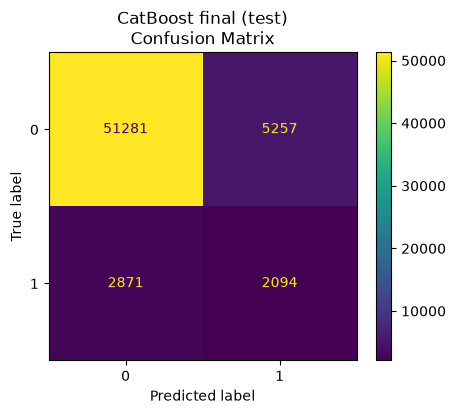

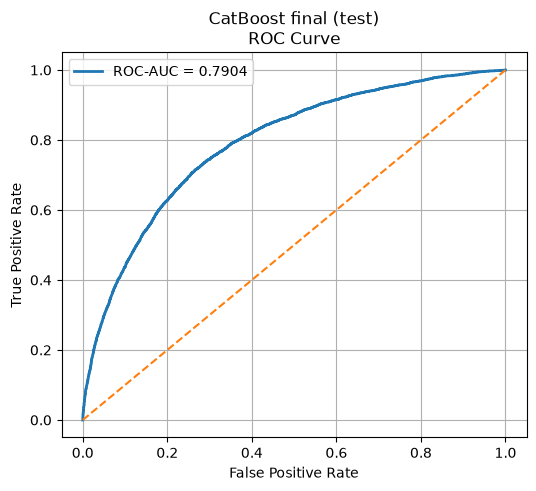

In [115]:
# final check on X_test: these clients were never used in any experiment, so this is the honest estimate
# the final model uses the full feature set and the default catboost settings:
# the tuned ones were not better on the business metric (cost of mistakes)
X_train_final = add_balances(add_installments(add_previous(add_bureau(X_train_cat))))
X_test_final = add_balances(add_installments(add_previous(add_bureau(X_test_cat))))

print(f"X_train_final: {X_train_final.shape}, X_test_final: {X_test_final.shape}")

final_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=3,
    verbose=0
)
final_model.fit(X_train_final, y_train, cat_features=cat_features)

final_result = evaluate_model(
    final_model,
    X_test_final,
    y_test,
    'CatBoost final (test)',
    threshold=final_threshold
)

In [116]:
# reference on the same test clients: the same catboost trained only on the application data
# the difference between the two rows is the effect of the credit history on unseen clients
reference_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=3,
    verbose=0
)
reference_model.fit(X_train_cat, y_train, cat_features=cat_features)

reference_result = evaluate_model(
    reference_model,
    X_test_cat,
    y_test,
    'CatBoost application only (test)',
    threshold=final_threshold,
    verbose=False
)

test_comparison = pd.DataFrame([reference_result, final_result])
test_comparison = test_comparison[['Model', 'Gini', 'PR_AUC', 'KS', 'Precision', 'Recall', 'Cost_per_100']]
test_comparison.to_csv('../reports/test_comparison.csv', index=False)
test_comparison.round(4)

,Model,Gini,PR_AUC,KS,Precision,Recall,Cost_per_100
0,CatBoost application only (test),0.5315,0.2520,0.4006,0.2693,0.3752,33.4390
1,CatBoost final (test),0.5808,0.2838,0.4493,0.2849,0.4218,31.8879


## Калибровка и риск-децили

mean predicted probability: 0.0802
actual default rate: 0.0807
brier score: 0.0657


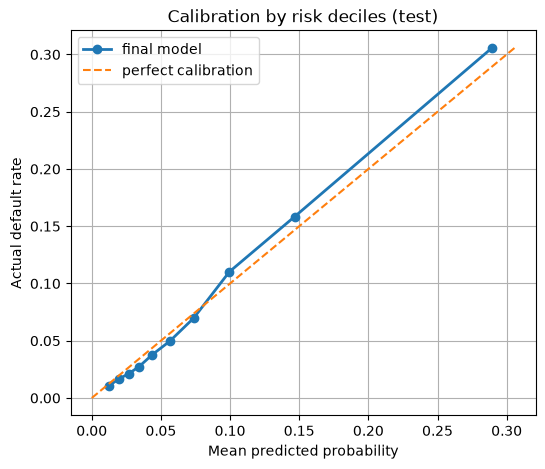

,clients,mean_proba,default_rate,defaults,share_of_defaults
decile,,,,,
1,6151,0.0121,0.0104,64,0.0129
2,6150,0.0197,0.0167,103,0.0207
3,6150,0.0266,0.0211,130,0.0262
4,6150,0.0343,0.0275,169,0.0340
5,6151,0.0438,0.0379,233,0.0469
6,6150,0.0564,0.0496,305,0.0614
7,6150,0.0737,0.0698,429,0.0864
8,6150,0.0995,0.1102,678,0.1366
9,6150,0.1467,0.1584,974,0.1962


In [117]:
# calibration: the threshold 1 / (1 + ratio) is correct only if the predicted probabilities are real probabilities
y_test_proba = final_model.predict_proba(X_test_final)[:, 1]

print(f"mean predicted probability: {y_test_proba.mean():.4f}")
print(f"actual default rate: {y_test.mean():.4f}")
print(f"brier score: {brier_score_loss(y_test, y_test_proba):.4f}")

# risk deciles: test clients are split into 10 equal groups from the safest (1) to the riskiest (10)
deciles = pd.DataFrame({
    'proba': y_test_proba,
    'target': y_test.values
})
deciles['decile'] = pd.qcut(deciles['proba'], 10, labels=range(1, 11))

decile_table = deciles.groupby('decile', observed=True).agg(
    clients=('target', 'size'),
    mean_proba=('proba', 'mean'),
    default_rate=('target', 'mean'),
    defaults=('target', 'sum')
)
# which share of all the defaulters falls into each group
decile_table['share_of_defaults'] = decile_table['defaults'] / decile_table['defaults'].sum()

# calibration plot: for a calibrated model the points lie on the diagonal
max_value = max(decile_table['mean_proba'].max(), decile_table['default_rate'].max())

plt.figure(figsize=(6, 5))
plt.plot(
    decile_table['mean_proba'],
    decile_table['default_rate'],
    marker='o',
    linewidth=2,
    label='final model'
)
plt.plot(
    [0, max_value],
    [0, max_value],
    '--',
    label='perfect calibration'
)
plt.xlabel('Mean predicted probability')
plt.ylabel('Actual default rate')
plt.title('Calibration by risk deciles (test)')
plt.legend()
plt.grid(True)
plt.show()

decile_table.round(4)

In [118]:
# operating points: what the business can choose from with the same model
# for each target recall: the needed threshold, the precision and the share of rejected applications
order = np.argsort(-y_test_proba)
sorted_target = y_test.values[order]
sorted_proba = y_test_proba[order]
caught = np.cumsum(sorted_target)
total_defaults = sorted_target.sum()

operating_points = []

for target_recall in [0.3, 0.4, 0.5, 0.6, 0.75, 0.8]:
    k = min(np.searchsorted(caught, target_recall * total_defaults), len(caught) - 1)
    operating_points.append({
        'recall': target_recall,
        'threshold': sorted_proba[k],
        'precision': caught[k] / (k + 1),
        'rejected_share': (k + 1) / len(sorted_target)
    })

# the current cost-based threshold for comparison
current_pred = (y_test_proba >= final_threshold).astype(int)
print(
    f"current threshold {final_threshold:.4f}: recall={recall_score(y_test, current_pred):.3f}, "
    f"precision={precision_score(y_test, current_pred):.3f}, rejected_share={current_pred.mean():.3f}"
)

pd.DataFrame(operating_points).round(4)

current threshold 0.1667: recall=0.422, precision=0.285, rejected_share=0.120


,recall,threshold,precision,rejected_share
0,0.30,0.2192,0.3406,0.0711
1,0.40,0.1762,0.2969,0.1088
2,0.50,0.1396,0.2558,0.1578
3,0.60,0.1120,0.2271,0.2133
4,0.75,0.0752,0.1777,0.3408
5,0.80,0.0637,0.1606,0.4020


## Интерпретация модели с помощью SHAP

In [120]:
# shap values: every prediction is split into additive contributions of the features
# prediction in log-odds = expected value + sum of the contributions of all the features
# catboost calculates exact shap values itself, including the categorical features
shap_sample = X_test_final.sample(5000, random_state=3)
shap_pool = Pool(shap_sample, cat_features=cat_features)

shap_matrix = final_model.get_feature_importance(shap_pool, type='ShapValues')
# the last column is the expected value (the same for all the clients), the rest are the contributions
expected_value = shap_matrix[0, -1]
shap_values = pd.DataFrame(shap_matrix[:, :-1], columns=shap_sample.columns, index=shap_sample.index)

print(f"shap values: {shap_values.shape}")
print(f"expected value: {expected_value:.4f} in log-odds, {1 / (1 + np.exp(-expected_value)):.4f} as probability")

# sanity check: expected value + sum of the contributions must give exactly the model prediction
raw_prediction = final_model.predict(shap_pool, prediction_type='RawFormulaVal')
print(f"max difference with the model prediction: {np.abs(expected_value + shap_values.sum(axis=1) - raw_prediction).max():.6f}")

shap values: (5000, 170)
expected value: -2.8627 in log-odds, 0.0540 as probability
max difference with the model prediction: 0.000000


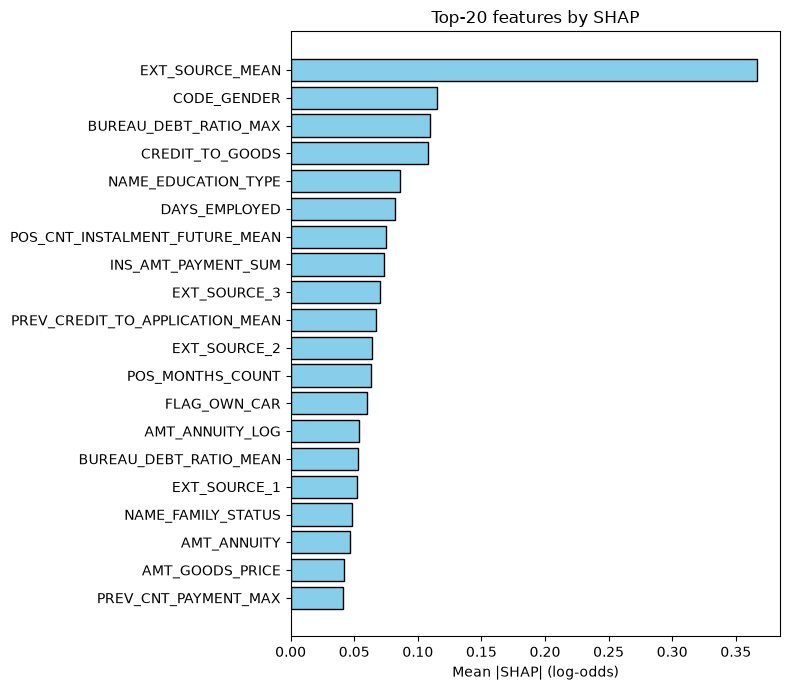

share of the model decisions by data source:
application             0.532
previous_application    0.136
bureau                  0.120
installments            0.115
pos_cash                0.063
credit_card             0.034
dtype: float64


In [ ]:
# global importance: mean absolute contribution of each feature over the sampled clients
mean_abs_shap = shap_values.abs().mean().sort_values(ascending=False)
top_features = mean_abs_shap.head(20)

plt.figure(figsize=(8, 7))
plt.barh(
    top_features.index[::-1],
    top_features.values[::-1],
    color='skyblue',
    edgecolor='black'
)
plt.xlabel('Mean |SHAP| (log-odds)')
plt.title('Top 20 features by SHAP')
plt.tight_layout()
plt.show()


# the same grouped by the data source: how much of the decisions relies on the credit history
def feature_source(col):
    if col.startswith('BUREAU'):
        return 'bureau'
    if col.startswith('PREV') or col == 'CURRENT_TO_PREV_CREDIT':
        return 'previous_application'
    if col.startswith('INS'):
        return 'installments'
    if col.startswith('POS'):
        return 'pos_cash'
    if col.startswith('CC'):
        return 'credit_card'
    return 'application'


source_importance = mean_abs_shap.groupby(mean_abs_shap.index.map(feature_source)).sum()
source_importance = (source_importance / source_importance.sum()).sort_values(ascending=False)

print("share of the model decisions by data source:")
print(source_importance.round(3))

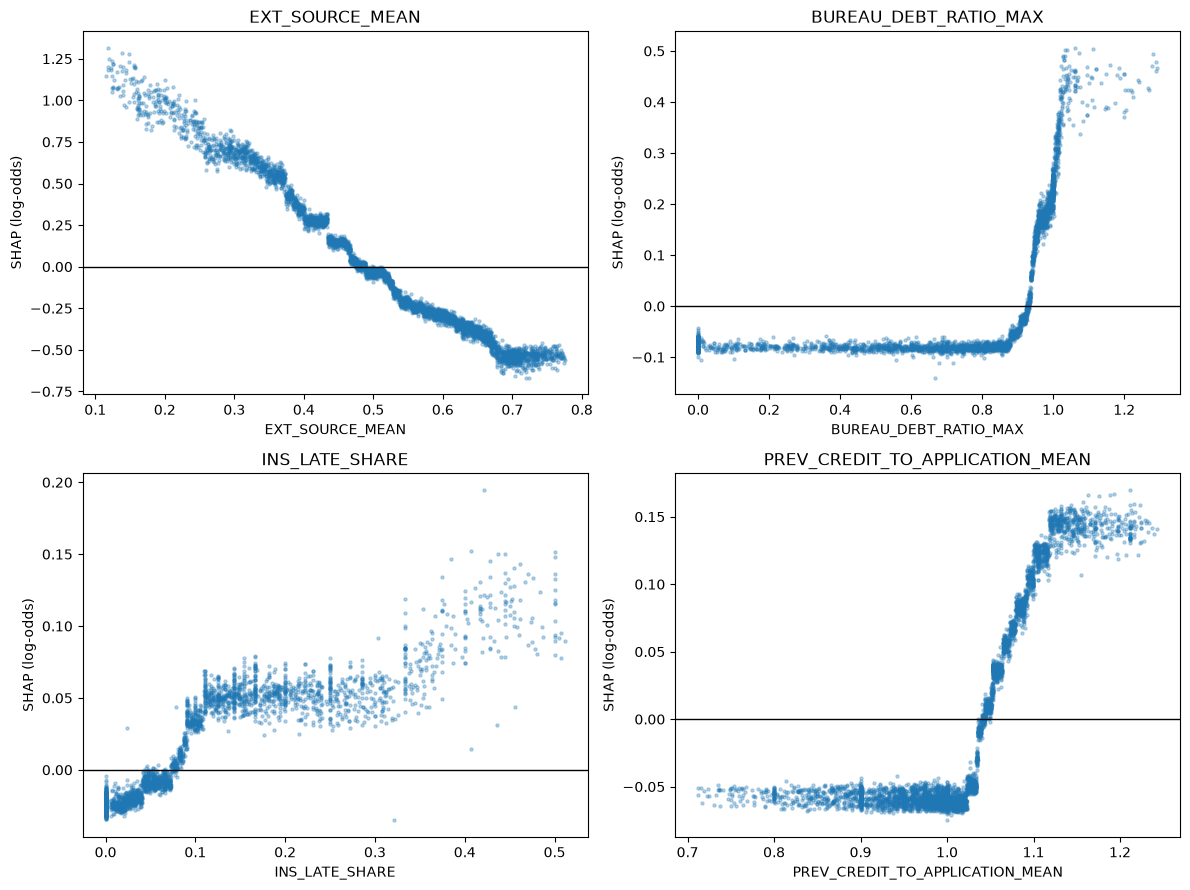

EXT_SOURCE_MEAN: missing for 0.1% of clients, mean contribution when missing +1.0058
BUREAU_DEBT_RATIO_MAX: missing for 16.8% of clients, mean contribution when missing -0.0733
INS_LATE_SHARE: missing for 5.3% of clients, mean contribution when missing -0.0248
PREV_CREDIT_TO_APPLICATION_MEAN: missing for 5.8% of clients, mean contribution when missing -0.0529


In [122]:
# direction of the influence: how the value of a feature moves the risk
# every point is a client: x - the value of the feature, y - its contribution to the risk
dependence_features = ['EXT_SOURCE_MEAN', 'BUREAU_DEBT_RATIO_MAX', 'INS_LATE_SHARE', 'PREV_CREDIT_TO_APPLICATION_MEAN']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(dependence_features):
    values = shap_sample[col]
    # extreme values are cut off only on the plot to keep the main part readable, nan are not drawn
    mask = values.between(values.quantile(0.01), values.quantile(0.99))

    axes[i].scatter(
        values[mask],
        shap_values.loc[mask, col],
        s=5,
        alpha=0.3
    )
    axes[i].axhline(0, color='black', linewidth=1)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SHAP (log-odds)')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# clients without this history are not on the plots, their mean contribution is shown separately
for col in dependence_features:
    missing = shap_sample[col].isna()
    if missing.any():
        print(f"{col}: missing for {missing.mean():.1%} of clients, mean contribution when missing {shap_values.loc[missing, col].mean():+.4f}")

In [123]:
# sensitive features: gender, age and family status are restricted in credit decisions in many countries
sensitive = ['CODE_GENDER', 'DAYS_BIRTH', 'AGE', 'NAME_FAMILY_STATUS', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS']
ranks = mean_abs_shap.rank(ascending=False).astype(int)

sensitive_table = pd.DataFrame({
    'rank': ranks[sensitive],
    'share_of_importance': mean_abs_shap[sensitive] / mean_abs_shap.sum()
}).sort_values('rank')

print(f"features in the model: {len(mean_abs_shap)}")
print(sensitive_table.round(4))

# how gender moves the risk: mean contribution for each value (positive - higher risk)
print("\nmean contribution of CODE_GENDER by value:")
print(shap_values['CODE_GENDER'].groupby(shap_sample['CODE_GENDER']).agg(['mean', 'size']).round(4))

features in the model: 170
                    rank  share_of_importance
CODE_GENDER            2               0.0361
NAME_FAMILY_STATUS    17               0.0150
DAYS_BIRTH            31               0.0097
AGE                   49               0.0064
CNT_FAM_MEMBERS      139               0.0003
CNT_CHILDREN         158               0.0000

mean contribution of CODE_GENDER by value:
               mean  size
CODE_GENDER              
F           -0.0916  3296
M            0.1609  1704


client 346468: probability of default 78.35%, decision: reject
  EXT_SOURCE_MEAN = 0.230: increases the risk (+0.772)
  POS_CNT_INSTALMENT_FUTURE_MEAN = 26.25: increases the risk (+0.345)
  CC_CNT_DRAWINGS_ATM_MEAN = 2.857: increases the risk (+0.338)
  CREDIT_TO_GOODS = 1.317: increases the risk (+0.172)
  CODE_GENDER = M: increases the risk (+0.167)
  EXT_SOURCE_2 = 0.161: increases the risk (+0.128)
  CC_DRAWINGS_TO_LIMIT_MEAN = 0.129: increases the risk (+0.124)
  INS_1Y_DPD_MAX = 16.0: increases the risk (+0.123)
  PREV_CREDIT_TO_APPLICATION_MEAN = 1.110: increases the risk (+0.114)
  POS_MONTHS_COUNT = 4.000: increases the risk (+0.108)


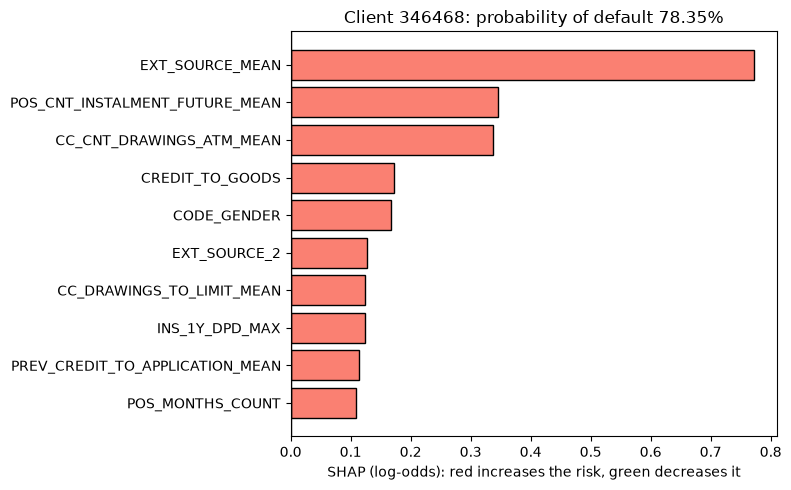

client 366251: probability of default 3.00%, decision: approve
  EXT_SOURCE_MEAN = 0.709: decreases the risk (-0.583)
  BUREAU_DEBT_RATIO_MAX = 1.000: increases the risk (+0.244)
  CODE_GENDER = M: increases the risk (+0.159)
  EXT_SOURCE_2 = 0.726: decreases the risk (-0.157)
  CREDIT_TO_GOODS = 1.000: decreases the risk (-0.111)
  EXT_SOURCE_3 = 0.693: decreases the risk (-0.088)
  AMT_GOODS_PRICE = 679500.000: decreases the risk (-0.086)
  DAYS_EMPLOYED = -1053.000: increases the risk (+0.085)
  FLAG_OWN_CAR = Y: decreases the risk (-0.084)
  POS_MONTHS_COUNT = 7.000: increases the risk (+0.071)


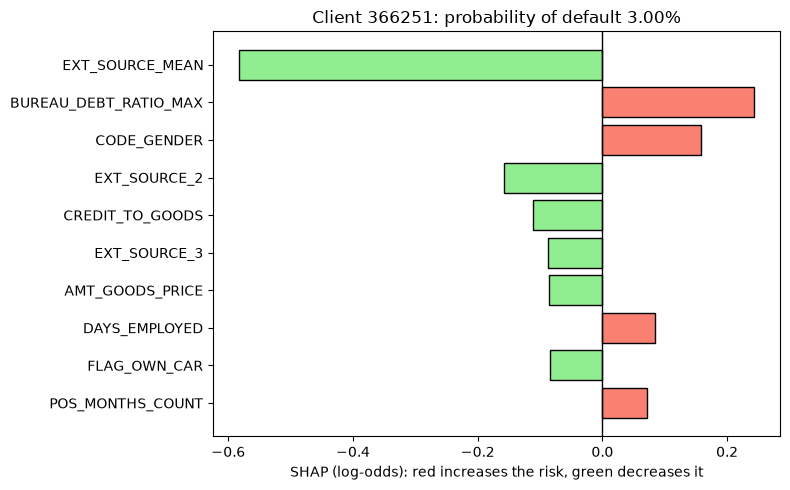

In [124]:
# explanation of one decision: the main reasons that moved the risk of a client up and down
def explain_client(client_id, top_n=10):
    contributions = shap_values.loc[client_id].sort_values(key=np.abs, ascending=False).head(top_n)
    probability = final_model.predict_proba(shap_sample.loc[[client_id]])[0, 1]
    decision = 'reject' if probability >= final_threshold else 'approve'

    print(f"client {client_id}: probability of default {probability:.2%}, decision: {decision}")
    for col, contribution in contributions.items():
        value = shap_sample.loc[client_id, col]
        value = f"{value:.3f}" if isinstance(value, float) else value
        direction = 'increases' if contribution > 0 else 'decreases'
        print(f"  {col} = {value}: {direction} the risk ({contribution:+.3f})")

    colors = ['salmon' if c > 0 else 'lightgreen' for c in contributions.values[::-1]]

    plt.figure(figsize=(8, 5))
    plt.barh(
        contributions.index[::-1],
        contributions.values[::-1],
        color=colors,
        edgecolor='black'
    )
    plt.axvline(0, color='black', linewidth=1)
    plt.xlabel('SHAP (log-odds): red increases the risk, green decreases it')
    plt.title(f'Client {client_id}: probability of default {probability:.2%}')
    plt.tight_layout()
    plt.show()


sample_proba = final_model.predict_proba(shap_pool)[:, 1]

# the riskiest client of the sample and a typical approved one (probability close to 3%)
rejected_client = shap_sample.index[np.argmax(sample_proba)]
approved_client = shap_sample.index[np.argmin(np.abs(sample_proba - 0.03))]

explain_client(rejected_client)
explain_client(approved_client)

### Признаки кредитной истории доступны только для клиентов, которые есть в таблице истории. Для нового клиента эти признаки пусты, а такое сочетание модель почти не видела при обучении, поэтому её оценка окажется смещённой для такого клиенты. Для таких клиентов будем использовать резервную модель, обученную только на данных анкеты. Она слабее основной, но корректна для клиентов без известной истории. threshold подбирался по цене ошибок исходя из интересов для "бизнеса".

## Резервная модель для клиентов без кредитной истории

### Посмотрим, на разницу в предсказаниях модели для пользователя с пустой историей против модели, в которой эта история вообще не учитывается 

In [125]:
# fallback for the clients that are not in the history table
# without it the final model would get an empty history and treat such a client
# as a person who never had any credit, which is a separate risk group
history_cols = [col for col in X_test_final.columns if col not in X_test_cat.columns]
count_cols = [
    'BUREAU_COUNT', 'BUREAU_ACTIVE_COUNT', 'PREV_COUNT', 'PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT',
    'INS_COUNT', 'INS_1Y_COUNT', 'POS_MONTHS_COUNT', 'CC_MONTHS_COUNT'
]

# the test clients exactly as the bot would see them if their SK_ID_CURR was not found
X_test_no_history = X_test_final.copy()
X_test_no_history[history_cols] = np.nan
X_test_no_history[count_cols] = 0

no_history_result = evaluate_model(
    final_model,
    X_test_no_history,
    y_test,
    'final model, history removed (test)',
    threshold=final_threshold,
    verbose=False
)

fallback_comparison = pd.DataFrame([no_history_result, reference_result])
# mean predicted probability vs the actual default rate: shows whether the probabilities can be trusted
fallback_comparison['mean_proba'] = [
    final_model.predict_proba(X_test_no_history)[:, 1].mean(),
    reference_model.predict_proba(X_test_cat)[:, 1].mean()
]

print(f"actual default rate: {y_test.mean():.4f}")
fallback_comparison[['Model', 'Gini', 'PR_AUC', 'Precision', 'Recall', 'Cost_per_100', 'mean_proba']].round(4)

actual default rate: 0.0807


,Model,Gini,PR_AUC,Precision,Recall,Cost_per_100,mean_proba
0,"final model, history removed (test)",0.5111,0.2353,0.2768,0.2844,34.8845,0.0716
1,CatBoost application only (test),0.5315,0.2520,0.2693,0.3752,33.4390,0.0804


## Организация файлов для бота



In [126]:
# saving everything the bot needs for the final model
# the model uses the application data and the credit history, the bot finds the history by SK_ID_CURR
models_dir = '../models'

final_model.save_model(os.path.join(models_dir, 'catboost_model.cbm'))
# fallback model for the clients without a known credit history: the same catboost, application data only
reference_model.save_model(os.path.join(models_dir, 'catboost_model_application.cbm'))
joblib.dump(list(X_cat.columns), os.path.join(models_dir, 'raw_features.joblib'))
joblib.dump(cat_features, os.path.join(models_dir, 'cat_features.joblib'))
joblib.dump(list(X_train_final.columns), os.path.join(models_dir, 'model_features.joblib'))
joblib.dump(final_threshold, os.path.join(models_dir, 'threshold.joblib'))

# history aggregates of all the clients in one table (it is big, so it goes to data/, not to git)
history_features = pd.concat([bureau_agg, previous_agg, installments_agg, pos_agg, credit_card_agg], axis=1)
history_features.index.name = 'SK_ID_CURR'
history_features.to_parquet('../data/history_features.parquet')

# examples for the bot: test clients the model has never seen, SK_ID_CURR is a column
examples = X_test_cat.head(10).reset_index()
examples.to_csv('../examples/test_clients.csv', index=False)

with open('../examples/example_input.json', 'w', encoding='utf-8') as f:
    json.dump(json.loads(examples.iloc[[0]].to_json(orient='records'))[0], f, ensure_ascii=False, indent=4)

print(f"model features: {len(X_train_final.columns)}, raw features: {len(X_cat.columns)}, categorical: {len(cat_features)}")
print(f"history table: {history_features.shape[0]:,} clients, {history_features.shape[1]} features")
print(f"threshold: {final_threshold:.4f}")

model features: 170, raw features: 62, categorical: 13
history table: 353,895 clients, 105 features
threshold: 0.1667


In [92]:
# # saving a consistent set of files for the bot: model, feature lists and threshold
# # cat was trained on X_train_part, whose columns keep the original get_dummies names -
# # exactly the names the bot gets from pd.get_dummies at inference time
# models_dir = '../models'

# cat.save_model(os.path.join(models_dir, 'catboost_model.cbm'))
# joblib.dump(list(X_train_part.columns), os.path.join(models_dir, 'model_features.joblib'))

# raw_features = [col for col in df.columns if col != 'TARGET']
# joblib.dump(raw_features, os.path.join(models_dir, 'raw_features.joblib'))

# joblib.dump(final_threshold, os.path.join(models_dir, 'threshold.joblib'))

# print(f"saved to: {os.path.abspath(models_dir)}")
# print(f"model features: {len(X_train_part.columns)}")
# print(f"raw features: {len(raw_features)}")
# print(f"threshold: {final_threshold:.4f}")